# Kiểm thử pipeline image_processor
Notebook này tái hiện từng bước chính của `sam3/backend/image_processor.py` để dễ dàng verify và kiểm thử.
Các section gồm: thiết lập môi trường, chạy SAM3 mask, matting, depth order, inpaint layer và inpaint background tổng thể.

In [1]:
import sys
from pathlib import Path
import io, base64, logging
from dataclasses import dataclass, field
from typing import List, Tuple
import numpy as np
import cv2
from PIL import Image
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'examples':
    ROOT = ROOT.parent

# Add backend to path so relative imports in image_processor work
backend_path = ROOT / 'backend'
if str(backend_path) not in sys.path:
    sys.path.insert(0, str(backend_path))
sys.path.insert(0, str(ROOT))

from backend.image_processor import _TH_ALPHA, _KERNEL_SCALE, _UNBLEND_ALPHA_CLIP, _PALETTE_PERCENTILE, _FG_REFINE_NUM_COLORS, _BG_REFINE_NUM_COLORS, _FG_REFINE_N_INNER_RATIO, _BG_REFINE_N_OUTER_RATIO
from backend.models import get_sam3_processor, get_lama_model, get_matting_model
from backend.helpers import (estimate_fg_color, estimate_fg_alpha, refine_background, expand_mask, find_flat_color_region_ccs, shrink_mask_ratio, expand_mask_ratio, divide_mask_to_connected_components)

print('ROOT =', ROOT)
print('Torch device available:', torch.cuda.is_available())

/home/intern/sam3/sam3/model_builder.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/intern/anaconda3/envs/sam3/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


ROOT = /home/intern/sam3
Torch device available: True


In [2]:
def _image_to_base64(img: Image.Image, fmt: str = 'PNG') -> str:
    buf = io.BytesIO()
    img.save(buf, format=fmt)
    return base64.b64encode(buf.getvalue()).decode()

def xyxy_to_xywh(box):
    xmin, ymin, xmax, ymax = box

    xmin = int(xmin)
    ymin = int(ymin)
    xmax = int(xmax)
    ymax = int(ymax)

    w = xmax - xmin
    h = ymax - ymin

    return (xmin, ymin, w, h)

def _bbox_from_mask(mask: np.ndarray) -> Tuple[int, int, int, int] | None:
    rows = np.any(mask > 0, axis=1)
    cols = np.any(mask > 0, axis=0)
    if not rows.any():
        return None
    y0, y1 = np.where(rows)[0][[0, -1]]
    x0, x1 = np.where(cols)[0][[0, -1]]
    return int(x0), int(y0), int(x1 - x0 + 1), int(y1 - y0 + 1)

def _calc_kernel_size(image_np: np.ndarray) -> tuple[int, int]:
    h, w = image_np.shape[:2]
    return (round(h * _KERNEL_SCALE), round(w * _KERNEL_SCALE))

def _build_inpaint_mask(image_rgb: np.ndarray, hard_mask: np.ndarray, kernel_size: tuple[int, int]) -> np.ndarray:
    color_masks, _, ccs = find_flat_color_region_ccs(image_rgb, hard_mask, max_num_colors=_FG_REFINE_NUM_COLORS, percentile=_PALETTE_PERCENTILE)
    if len(ccs) == 0:
        return expand_mask(hard_mask, kernel_size)
    shrinked_ccs = [ccs[i] if len(color_masks[i]) == 0 else shrink_mask_ratio(ccs[i], _FG_REFINE_N_INNER_RATIO) for i in range(len(ccs))]
    combined = np.any(shrinked_ccs + sum(color_masks, []), axis=0)
    return expand_mask(combined, kernel_size)

def _get_bbox_intersection(bbox1: list, bbox2: list):
    """Tính toán vùng giao nhau giữa 2 Bounding Box."""
    x1, y1, w1, h1 = bbox1
    x2, y2, w2, h2 = bbox2
    
    l, t = max(x1, x2), max(y1, y2)
    r, b = min(x1 + w1, x2 + w2), min(y1 + h1, y2 + h2)
    
    if l >= r or t >= b:
        return None
    return [l, t, r - l, b - t]

def _refine_alpha_with_colors(image_rgb: np.ndarray, bg_np: np.ndarray, alpha: np.ndarray, hard_mask: np.ndarray, kernel_size: tuple[int, int]) -> tuple[np.ndarray, np.ndarray]:
    image_uint8 = image_rgb.astype(np.uint8)
    alpha = alpha.astype(np.float64)
    fg_rgb = estimate_fg_color(image_uint8, bg_np.astype(np.uint8), alpha, _UNBLEND_ALPHA_CLIP)
    color_masks, colors, ccs = find_flat_color_region_ccs(image_uint8, hard_mask, max_num_colors=_FG_REFINE_NUM_COLORS, percentile=_PALETTE_PERCENTILE)
    for colors_cc, color_masks_cc, cc in zip(colors, color_masks, ccs):
        _ref_alpha = np.zeros_like(alpha)
        _ref_color = np.zeros_like(fg_rgb)
        _nonzero = np.zeros_like(alpha)
        for color, cmask in zip(colors_cc, color_masks_cc):
            cmask_exp = expand_mask(cmask, kernel_size)
            ra = estimate_fg_alpha(cmask_exp, color, bg_np.astype(np.uint8), image_uint8)
            if ra is not None:
                _ref_alpha = np.maximum(_ref_alpha, ra)
                _ref_color[ra > 0] = color
                _nonzero += (ra > 0).astype(int)
        boundary = _nonzero > 1
        if _ref_alpha.sum() > 0:
            inner_cc = (~shrink_mask_ratio(cc, _FG_REFINE_N_INNER_RATIO)) & cc
            target = ((alpha == 0) | inner_cc) & (~boundary)
            alpha[target] = np.maximum(alpha[target], _ref_alpha[target])
            upd = target & (_ref_alpha > 0)
            fg_rgb[upd] = _ref_color[upd]
    return alpha, fg_rgb

def _estimate_depth_order(masks: List[np.ndarray]) -> List[int]:
    n = len(masks)
    overlap_scores = np.zeros(n)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            mi = masks[i].astype(bool)
            mj = masks[j].astype(bool)
            intersection = np.sum(mi & mj)
            if intersection == 0:
                continue
            ratio_i = intersection / np.sum(mi)
            ratio_j = intersection / np.sum(mj)
            if ratio_i > ratio_j:
                overlap_scores[i] += intersection
    return list(np.argsort(overlap_scores))

def _remove_occluder_with_seed(image_np: np.ndarray, target_mask: np.ndarray, occluder_mask: np.ndarray, lama, orig_size: tuple) -> np.ndarray:
    overlap = target_mask & occluder_mask
    if not np.any(overlap):
        return image_np.copy()
    visible_B = target_mask & (~occluder_mask)
    if np.sum(visible_B) == 0:
        return image_np.copy()
    B_colors = image_np[visible_B]
    B_mean_color = np.median(B_colors, axis=0).astype(np.uint8)
    seeded = image_np.copy()
    seeded[overlap] = B_mean_color
    kernel = np.ones((7, 7), np.uint8)
    overlap_u8 = overlap.astype(np.uint8) * 255
    eroded = cv2.erode(overlap_u8, kernel, iterations=2)
    inpaint_region = overlap_u8 & ~eroded
    if np.sum(inpaint_region) == 0:
        return seeded
    mask_pil = Image.fromarray(inpaint_region).convert('L')
    result = lama(Image.fromarray(seeded), mask_pil)
    if result.size != orig_size:
        result = result.resize(orig_size, Image.LANCZOS)
    return np.array(result.convert('RGB'), dtype=np.uint8)

def _build_source_image_for_object(original_np: np.ndarray, masks: List[np.ndarray], target_idx: int, depth_order: List[int], lama, orig_size: tuple) -> np.ndarray:
    target_pos = depth_order.index(target_idx)
    objects_above = depth_order[:target_pos]
    target_mask = masks[target_idx].astype(bool)
    occluders = [i for i in objects_above if np.any(masks[i].astype(bool) & target_mask)]
    if not occluders:
        return original_np.copy()
    current = original_np.copy()
    for occ_idx in occluders:
        current = _remove_occluder_with_seed(image_np=current, target_mask=target_mask, occluder_mask=masks[occ_idx].astype(bool), lama=lama, orig_size=orig_size)
    return current

Sử dụng ảnh: assets/images/composite.png


(-0.5, 6613.5, 4251.5, -0.5)

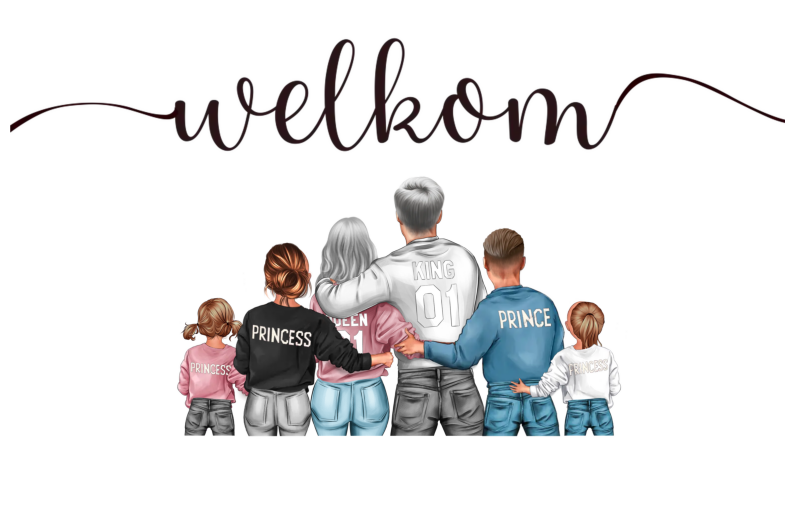

In [3]:
# Tải ảnh mẫu và hiển thị
sample_image_path = ROOT / 'assets/images/composite.png'
image = Image.open(sample_image_path).convert('RGB')
image_np = np.array(image, dtype=np.uint8)
print('Sử dụng ảnh:', sample_image_path.relative_to(ROOT))
plt.figure(figsize=(10, 8))
plt.imshow(image_np)
plt.axis('off')

checkpoints/sam3.pt
found 6 object(s)
Keyword=person masks= 6
  person_0 score=0.910
  person_1 score=0.898
  person_2 score=0.914
  person_3 score=0.914
  person_4 score=0.918
  person_5 score=0.891
Tổng mask thu được: 6


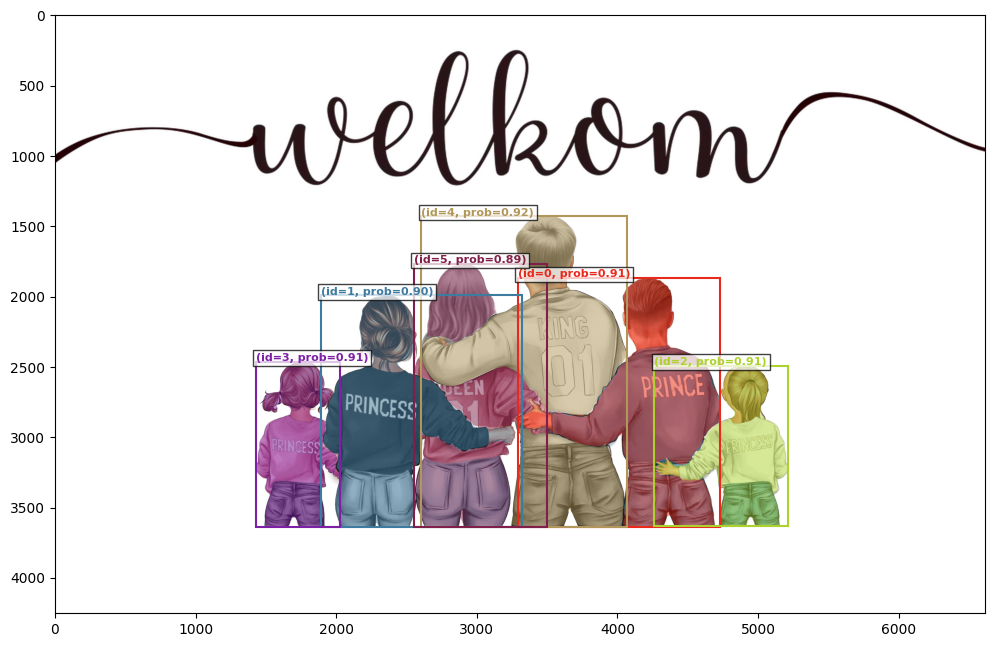

In [4]:
from sam3.visualization_utils import draw_box_on_image, normalize_bbox, plot_results
import os
os.chdir(str(ROOT))  # Change to root so relative checkpoint path works

processor = get_sam3_processor()
keywords = ['person']  
raw_masks = []
labels = []
scores = []
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
mixed_dtype = (torch.bfloat16
                   if device_type == "cuda" and torch.cuda.is_bf16_supported()
                   else torch.float16)

# Move set_image inside autocast context to ensure proper dtype handling
with torch.no_grad(), torch.autocast(device_type, dtype=mixed_dtype):
    inference_state = processor.set_image(image)
    for keyword in keywords:
        k = keyword.strip()
        if not k:
            continue
        processor.reset_all_prompts(inference_state)
        inference_state = processor.set_text_prompt(state=inference_state, prompt=k)
        plot_results(image, inference_state)
        masks = inference_state.get('masks')
        scores_local = inference_state.get('scores')
        print(f'Keyword={k} masks=', len(masks) if masks is not None else 0)
        if masks is None or len(masks) == 0:
            continue
        for i, mt in enumerate(masks):
            mn = mt.squeeze(0)
            if hasattr(mn, 'cpu'):
                mn = mn.cpu().numpy()
            bin_mask = (mn > 0).astype(np.uint8) * 255
            raw_masks.append(bin_mask)
            label = f'{k}_{i}' if len(masks) > 1 else k
            labels.append(label)
            score = scores_local[i].item() if scores_local is not None else 1.0
            scores.append(score)
            print(f'  {label} score={score:.3f}')
print('Tổng mask thu được:', len(raw_masks))

In [5]:
boxes = inference_state.get('boxes')
print(len(boxes), 'boxes thu được')

6 boxes thu được


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_amodal_recovery_multi(
    image_np: np.ndarray,
    target_mask: np.ndarray,
    final_filled_mask: np.ndarray,
    predicted_full_target: np.ndarray,
    occluder_masks: list[np.ndarray],
    overlap_mask: np.ndarray
):
    """
    Visualize:
    - target mask
    - overlap
    - predicted mask
    - nhiều occluder với màu khác nhau
    """

    target_bool = target_mask.astype(bool)
    overlap_bool = overlap_mask.astype(bool)

    h, w = target_mask.shape[:2]

    recovery_canvas = np.zeros((h, w, 3), dtype=np.uint8)

    recovery_canvas[target_bool] = [0, 255, 0]

    recovery_canvas[overlap_bool] = [255, 0, 0]

    # Overlay = ảnh gốc + occluders
    overlay = image_np.copy()

    # Mỗi occluder 1 màu
    colors = [
        [255, 0, 0],     # đỏ
        [0, 0, 255],     # xanh dương
        [255, 255, 0],   # vàng
        [255, 0, 255],   # tím
        [0, 255, 255],   # cyan
    ]

    alpha = 0.45

    for idx, occ_mask in enumerate(occluder_masks):

        occ_bool = occ_mask.astype(bool)

        color = np.array(
            colors[idx % len(colors)],
            dtype=np.uint8
        )

        overlay[occ_bool] = (
            (1 - alpha) * overlay[occ_bool]
            + alpha * color
        ).astype(np.uint8)


    plt.figure(figsize=(18, 10))

    plt.subplot(2, 3, 1)
    plt.title("1. Target Mask")
    plt.imshow(target_bool, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.title("2. Overlap Mask")
    plt.imshow(overlap_bool, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.title("3. Recovery\nGreen=Original | Red=Recovered")
    plt.imshow(recovery_canvas)
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.title("4. Recovered mask")
    plt.imshow(final_filled_mask, cmap='gray')
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.title("5. Original Image + Occluders")
    plt.imshow(overlay)
    plt.axis('off')

    plt.subplot(2, 3, 6)
    plt.title("6. Predicted Full Target")
    plt.imshow(predicted_full_target, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [7]:
print(boxes[0])

tensor([3290.1985, 1867.2422, 4733.1860, 3637.8914], device='cuda:0')


In [8]:
def get_expanded_overlap(mask: np.ndarray, overlap: np.ndarray, crack_thickness: int = 25) -> np.ndarray:
    """
    Return overlap that has been expanded to fill cracks/holes, without distorting the outer edges.
    = The part that is added compared to the original mask.
    """
    def to_u8(m):
        if m.dtype == bool: return m.astype(np.uint8) * 255
        return (m * 255).astype(np.uint8) if np.max(m) <= 1 else m.copy().astype(np.uint8)

    _, target_bin  = cv2.threshold(to_u8(mask), 127, 255, cv2.THRESH_BINARY)
    _, overlap_bin = cv2.threshold(to_u8(overlap), 127, 255, cv2.THRESH_BINARY)

    # Calculate kernel
    if crack_thickness is None:
        coords_overlap = cv2.findNonZero(overlap_bin)
        if coords_overlap is not None:
            _, _, w_ov, h_ov = cv2.boundingRect(coords_overlap)
            crack_thickness = max(7, int(min(h_ov, w_ov) * 0.15))
        else:
            crack_thickness = 7
            
    k = crack_thickness + (1 - crack_thickness % 2)

    # 3.Combine mask and find ROI
    combined = cv2.bitwise_or(target_bin, overlap_bin)
    coords_combined = cv2.findNonZero(combined)
    
    if coords_combined is None:
        return np.zeros_like(target_bin)
        
    x, y, w, h = cv2.boundingRect(coords_combined)
    H, W = combined.shape
    
    pad = k * 2
    x1, y1 = max(0, x - pad), max(0, y - pad)
    x2, y2 = min(W, x + w + pad), min(H, y + h + pad)

    # Extract ROI for processing
    roi_combined = combined[y1:y2, x1:x2]
    roi_target   = target_bin[y1:y2, x1:x2]
    rH, rW = roi_combined.shape

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))

    # dilate to fill crack
    dilated = cv2.dilate(roi_combined, kernel)
    flood = dilated.copy()
    ff = np.zeros((rH + 2, rW + 2), np.uint8)

    # flood fill to find holes after dilate
    cv2.floodFill(flood, ff, (0, 0), 255)
    dilated_filled = cv2.bitwise_or(dilated, cv2.bitwise_not(flood))

    # erode to restore original edges
    eroded = cv2.erode(dilated_filled, kernel)
    
    roi_result = cv2.bitwise_or(eroded, roi_combined)
    roi_expanded = cv2.subtract(roi_result, roi_target)

    # Put ROI back to full image
    result_full = np.zeros_like(target_bin)
    result_full[y1:y2, x1:x2] = roi_expanded

    return result_full

In [9]:
import cv2
import numpy as np

def calculate_multi_occluder_overlap(
    target_mask: np.ndarray,
    bbox_target: list,
    occluder_masks: list,
    bbox_occluders: list
):
    """
    Calculate overlap for an object with multiple occluders.
    """
    # Safe local type casting
    def safe_to_u8(m: np.ndarray) -> np.ndarray:
        if m.dtype == bool:
            return m.astype(np.uint8) * 255
        return (m * 255).astype(np.uint8) if np.max(m) <= 1 else m.copy().astype(np.uint8)

    target_u8 = safe_to_u8(target_mask)
    H, W = target_u8.shape

    x, y, w, h = bbox_target
    close_k_size = max(15, int(min(w, h) * 0.6))
    pad = close_k_size // 2

    x1 = max(0, x - pad);  x2 = min(W, x + w + pad)
    y1 = max(0, y - pad);  y2 = min(H, y + h + pad)

    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (close_k_size, close_k_size))
    
    closed_roi = cv2.morphologyEx(target_u8[y1:y2, x1:x2], cv2.MORPH_CLOSE, kernel_close)

    # Place result back into full frame
    predicted_full_target = np.zeros_like(target_u8)
    predicted_full_target[y1:y2, x1:x2] = closed_roi

    # Convert target to Boolean to accelerate intersection operations
    predicted_bool = predicted_full_target > 0

    combined_safe_overlap = np.zeros((H, W), dtype=bool)
    combined_safe_zone    = np.zeros((H, W), dtype=bool)

    for occ_mask, occ_bbox in zip(occluder_masks, bbox_occluders):

        intersect = _get_bbox_intersection(bbox_target, occ_bbox)
        if not intersect:
            continue

        ix, iy, iw, ih = intersect

        # Convert occluder mask to boolean
        occ_bool = safe_to_u8(occ_mask) > 0

        pred_roi = predicted_bool[iy:iy+ih, ix:ix+iw]
        occ_roi  = occ_bool[iy:iy+ih, ix:ix+iw]

        # Fast overlap calculation using bitwise AND (&)
        safe_overlap_roi = pred_roi & occ_roi

        # Update cumulative results using bitwise OR (|=)
        combined_safe_zone[iy:iy+ih, ix:ix+iw] = True
        combined_safe_overlap[iy:iy+ih, ix:ix+iw] |= safe_overlap_roi

    # Convert back to standard 8-bit image (0-255) for OpenCV
    combined_safe_zone_u8    = (combined_safe_zone.astype(np.uint8) * 255)
    combined_safe_overlap_u8 = (combined_safe_overlap.astype(np.uint8) * 255)


    # Call the CPU-optimized get_expanded_overlap
    expanded_overlap = get_expanded_overlap(target_u8, combined_safe_overlap_u8, crack_thickness=40)
    
    # Add the expanded patch to the original mask
    final_filled_mask = cv2.bitwise_or(target_u8, expanded_overlap)

    return predicted_full_target, combined_safe_zone_u8, combined_safe_overlap_u8, final_filled_mask

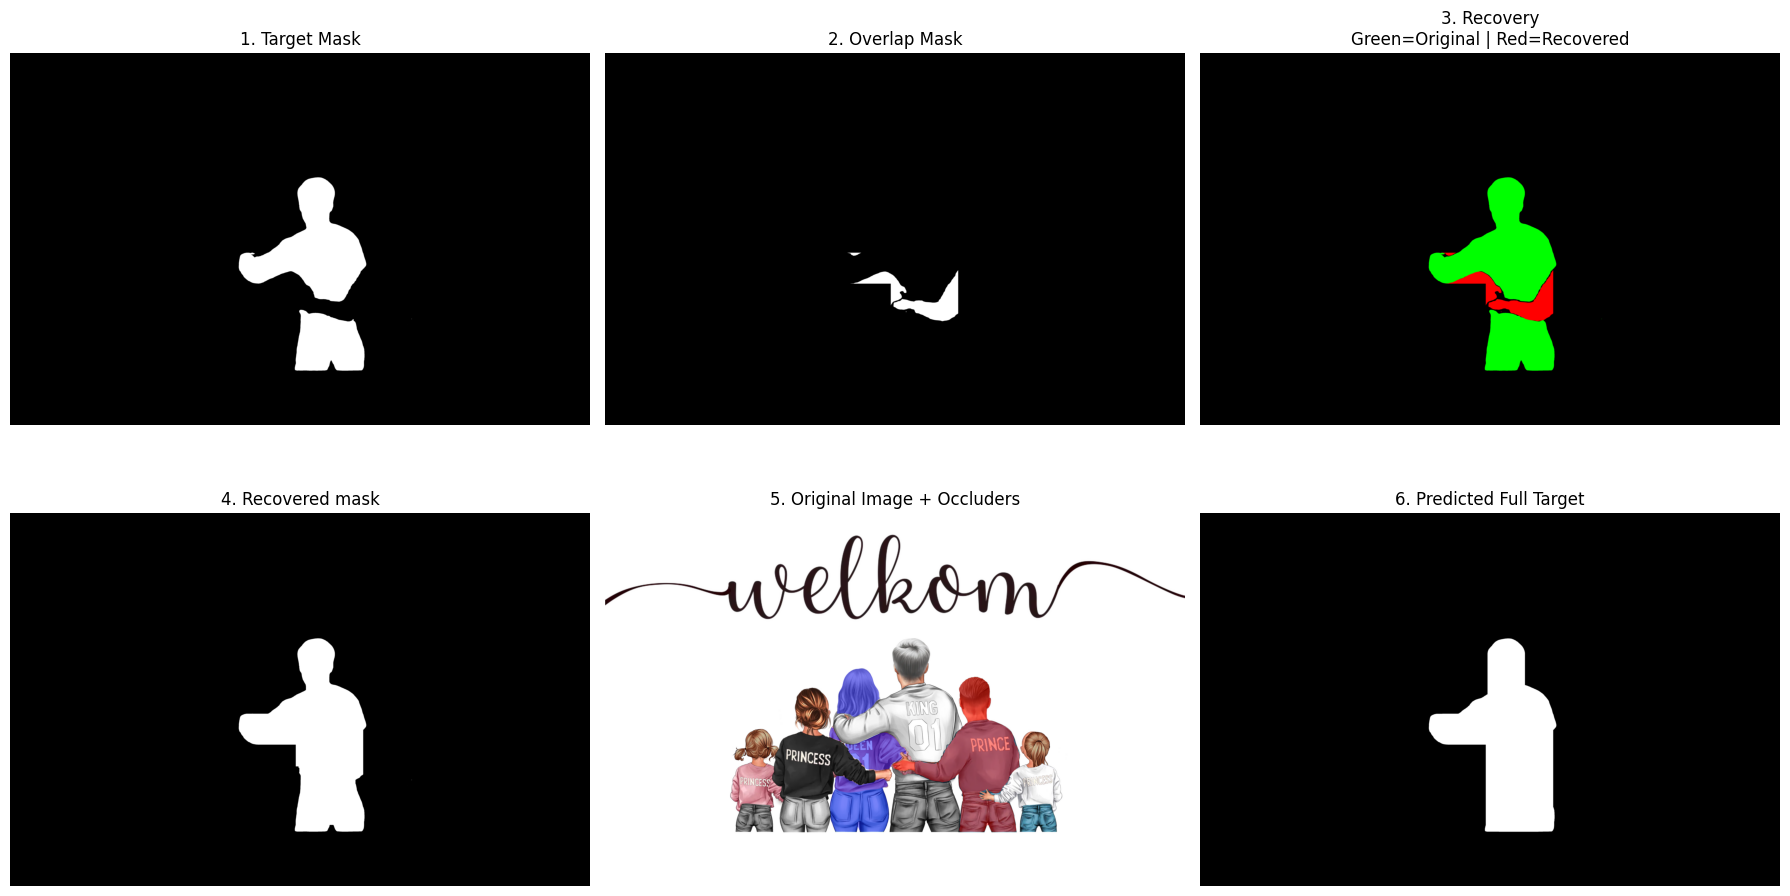

In [10]:
target_idx = 4
target_mask = raw_masks[target_idx]
bbox_target = xyxy_to_xywh(boxes[target_idx].detach().cpu().numpy())

occluder_indices = [0, 5]
occluder_masks = [raw_masks[i] for i in occluder_indices]
bbox_occluders = [xyxy_to_xywh(boxes[i].detach().cpu().numpy()) for i in occluder_indices]

predicted_full_target, combined_safe_zone, combined_safe_overlap, final_filled_mask = calculate_multi_occluder_overlap(
    target_mask=target_mask,
    bbox_target=bbox_target,
    occluder_masks=occluder_masks,
    bbox_occluders=bbox_occluders
)

visualize_amodal_recovery_multi(
    image_np=image_np,
    target_mask=target_mask,
    final_filled_mask=final_filled_mask,
    predicted_full_target=predicted_full_target,
    occluder_masks=occluder_masks,
    overlap_mask=combined_safe_overlap
)

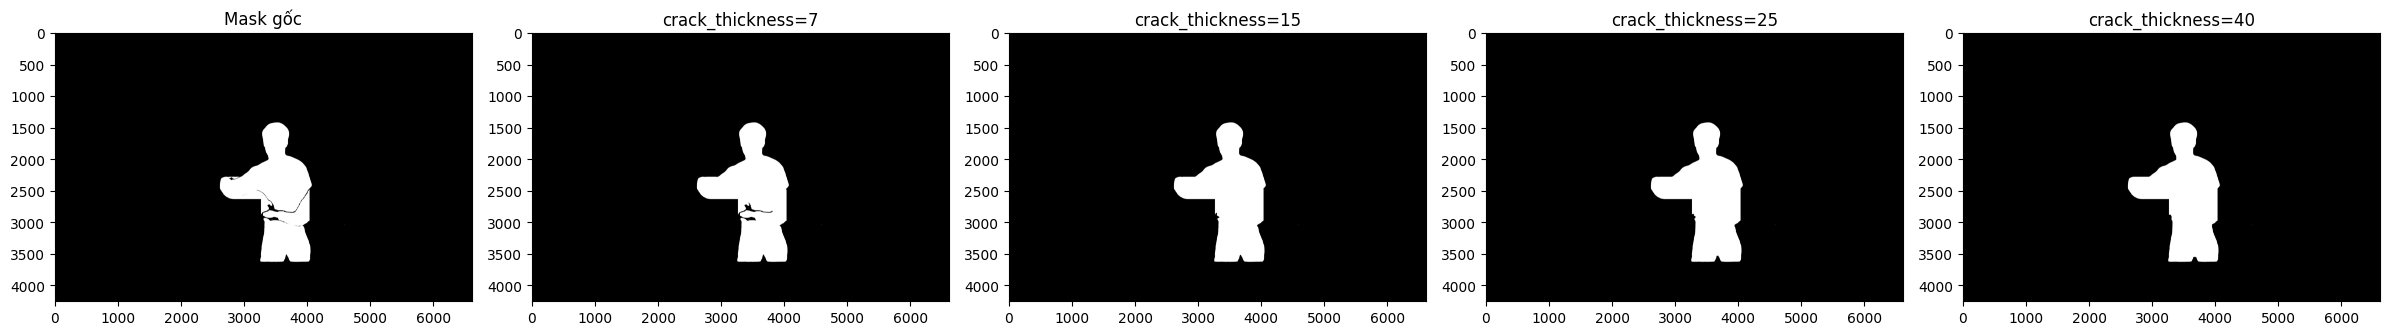

In [ ]:
# import cv2
# import numpy as np

# def fill_cracks(mask: np.ndarray, overlap: np.ndarray, 
#                 crack_thickness: int = None) -> np.ndarray:
#     """
#     Fill đường crack mỏng xuyên qua mask mà không làm biến dạng viền ngoài.
    
#     Strategy: 
#       - Dilate nhỏ để bịt crack
#       - Erode lại đúng lượng đó để restore viền ngoài  
#       - Kết quả: viền ngoài giữ nguyên, crack bên trong được lấp
#     """
#     def to_u8(m):
#         if m.dtype == bool: return m.astype(np.uint8) * 255
#         return (m * 255).astype(np.uint8) if np.max(m) <= 1 else m.copy().astype(np.uint8)

#     _, target_bin  = cv2.threshold(to_u8(mask),    127, 255, cv2.THRESH_BINARY)
#     _, overlap_bin = cv2.threshold(to_u8(overlap), 127, 255, cv2.THRESH_BINARY)

#     combined = cv2.bitwise_or(target_bin, overlap_bin)
#     H, W = combined.shape

#     # Ước tính độ dày crack nếu không truyền vào
#     if crack_thickness is None:
#         # Dựa vào kích thước overlap để ước tính
#         ys, xs = np.where(overlap_bin > 0)
#         if len(ys) > 0:
#             oh = int(ys.max()) - int(ys.min())
#             ow = int(xs.max()) - int(xs.min())
#             crack_thickness = max(7, int(min(oh, ow) * 0.15))
#         else:
#             crack_thickness = 7

#     # Đảm bảo lẻ
#     k = crack_thickness + (1 - crack_thickness % 2)

#     kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))

#     # ------------------------------------------------------------------ #
#     # BƯỚC 1: Dilate để bịt crack                                         #
#     # ------------------------------------------------------------------ #
#     dilated = cv2.dilate(combined, kernel, iterations=1)

#     # ------------------------------------------------------------------ #
#     # BƯỚC 2: Flood fill để lấp toàn bộ lỗ/vịnh còn lại sau dilate       #
#     # ------------------------------------------------------------------ #
#     flood = dilated.copy()
#     ff = np.zeros((H + 2, W + 2), np.uint8)
#     cv2.floodFill(flood, ff, (0, 0), 255)
#     holes = cv2.bitwise_not(flood)
#     dilated_filled = cv2.bitwise_or(dilated, holes)

#     # ------------------------------------------------------------------ #
#     # BƯỚC 3: Erode lại đúng lượng để restore viền ngoài                  #
#     # ------------------------------------------------------------------ #
#     eroded = cv2.erode(dilated_filled, kernel, iterations=1)

#     # ------------------------------------------------------------------ #
#     # BƯỚC 4: OR với combined gốc để đảm bảo không mất pixel nào         #
#     # (erode có thể ăn mất vài pixel nhỏ ở viền)                         #
#     # ------------------------------------------------------------------ #
#     result = cv2.bitwise_or(eroded, combined)

#     return result


# # ── Test nhiều giá trị crack_thickness ────────────────────────────────────
# def to_u8(m):
#     if m.dtype == bool: return m.astype(np.uint8) * 255
#     return (m * 255).astype(np.uint8) if np.max(m) <= 1 else m.copy().astype(np.uint8)

# original = cv2.bitwise_or(to_u8(target_mask), to_u8(combined_safe_overlap))

# thicknesses = [7, 15, 25, 40]
# fig, axes = plt.subplots(1, len(thicknesses) + 1, figsize=(24, 6))

# axes[0].set_title("Mask gốc")
# axes[0].imshow(original, cmap='gray')

# for ax, t in zip(axes[1:], thicknesses):
#     result = fill_cracks(target_mask, combined_safe_overlap, crack_thickness=t)
#     ax.set_title(f"crack_thickness={t}")
#     ax.imshow(result, cmap='gray')

# plt.tight_layout()
# plt.show()

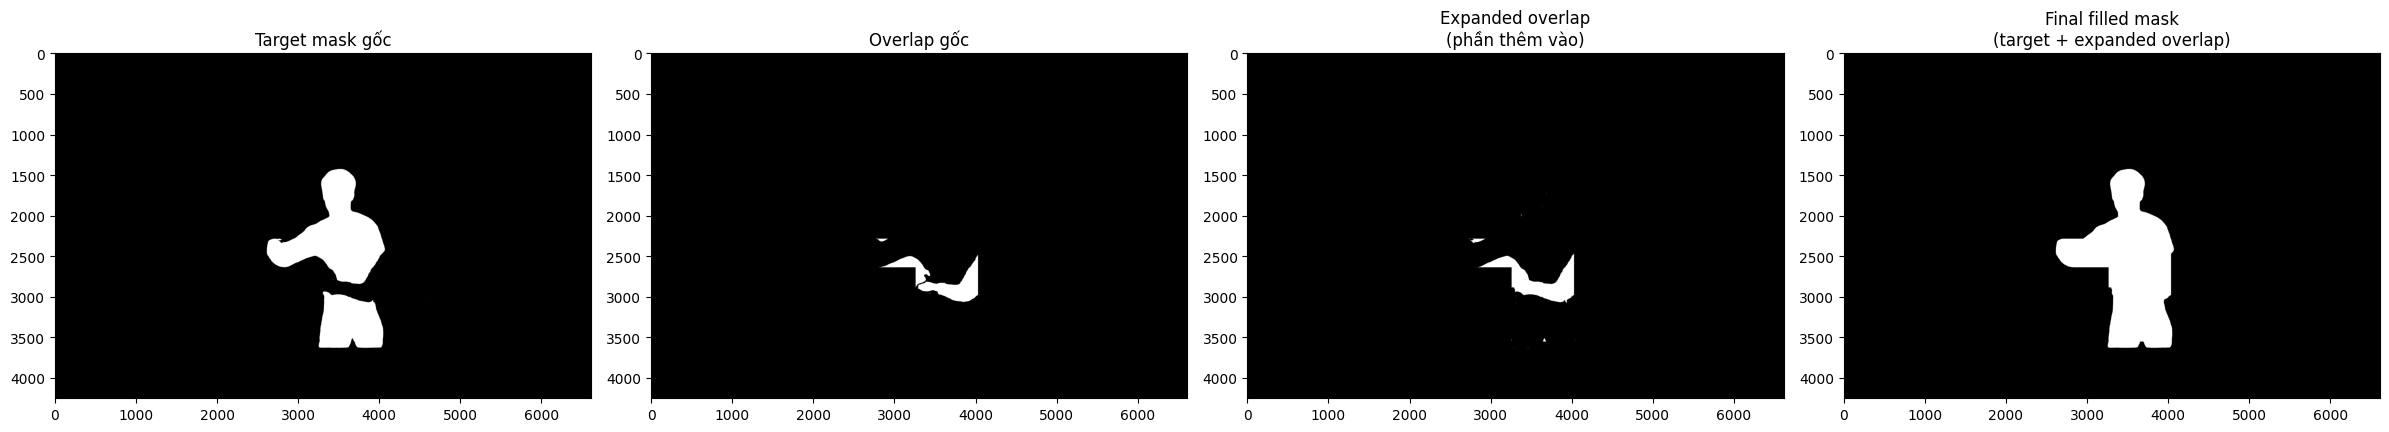

In [ ]:
def get_expanded_overlap(mask: np.ndarray, overlap: np.ndarray, crack_thickness: int = 25) -> np.ndarray:
    """
    Return overlap that has been expanded to fill cracks/holes, without distorting the outer edges.
    = The part that is added compared to the original mask.
    """
    def to_u8(m):
        if m.dtype == bool: return m.astype(np.uint8) * 255
        return (m * 255).astype(np.uint8) if np.max(m) <= 1 else m.copy().astype(np.uint8)

    _, target_bin  = cv2.threshold(to_u8(mask), 127, 255, cv2.THRESH_BINARY)
    _, overlap_bin = cv2.threshold(to_u8(overlap), 127, 255, cv2.THRESH_BINARY)

    # Calculate kernel
    if crack_thickness is None:
        coords_overlap = cv2.findNonZero(overlap_bin)
        if coords_overlap is not None:
            _, _, w_ov, h_ov = cv2.boundingRect(coords_overlap)
            crack_thickness = max(7, int(min(h_ov, w_ov) * 0.15))
        else:
            crack_thickness = 7
            
    k = crack_thickness + (1 - crack_thickness % 2)

    # 3.Combine mask and find ROI
    combined = cv2.bitwise_or(target_bin, overlap_bin)
    coords_combined = cv2.findNonZero(combined)
    
    if coords_combined is None:
        return np.zeros_like(target_bin)
        
    x, y, w, h = cv2.boundingRect(coords_combined)
    H, W = combined.shape
    
    pad = k * 2
    x1, y1 = max(0, x - pad), max(0, y - pad)
    x2, y2 = min(W, x + w + pad), min(H, y + h + pad)

    # Extract ROI for processing
    roi_combined = combined[y1:y2, x1:x2]
    roi_target   = target_bin[y1:y2, x1:x2]
    rH, rW = roi_combined.shape

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))

    # dilate to fill crack
    dilated = cv2.dilate(roi_combined, kernel)
    flood = dilated.copy()
    ff = np.zeros((rH + 2, rW + 2), np.uint8)

    # flood fill to find holes after dilate
    cv2.floodFill(flood, ff, (0, 0), 255)
    dilated_filled = cv2.bitwise_or(dilated, cv2.bitwise_not(flood))

    # erode to restore original edges
    eroded = cv2.erode(dilated_filled, kernel)
    
    roi_result = cv2.bitwise_or(eroded, roi_combined)
    roi_expanded = cv2.subtract(roi_result, roi_target)

    # Put ROI back to full image
    result_full = np.zeros_like(target_bin)
    result_full[y1:y2, x1:x2] = roi_expanded

    return result_full


# ── Visualize ──────────────────────────────────────────────────────────────
expanded_overlap = get_expanded_overlap(target_mask, combined_safe_overlap, crack_thickness=40)

def to_u8(m):
    if m.dtype == bool: return m.astype(np.uint8) * 255
    return (m * 255).astype(np.uint8) if np.max(m) <= 1 else m.copy().astype(np.uint8)

original_overlap = to_u8(combined_safe_overlap)
final_filled_mask = cv2.bitwise_or(to_u8(target_mask), expanded_overlap)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))
axes[0].set_title("Target mask gốc")
axes[0].imshow(to_u8(target_mask), cmap='gray')
axes[1].set_title("Overlap gốc")
axes[1].imshow(original_overlap, cmap='gray')
axes[2].set_title("Expanded overlap\n(phần thêm vào)")
axes[2].imshow(expanded_overlap, cmap='gray')
axes[3].set_title("Final filled mask\n(target + expanded overlap)")
axes[3].imshow(final_filled_mask, cmap='gray')
plt.tight_layout()
plt.show()

Đang tải mô hình Depth Estimation...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/503 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

Tải mô hình thành công!
Thứ tự chiều sâu (Từ trên xuống dưới): [0, 1, 4, 5, 2, 3]


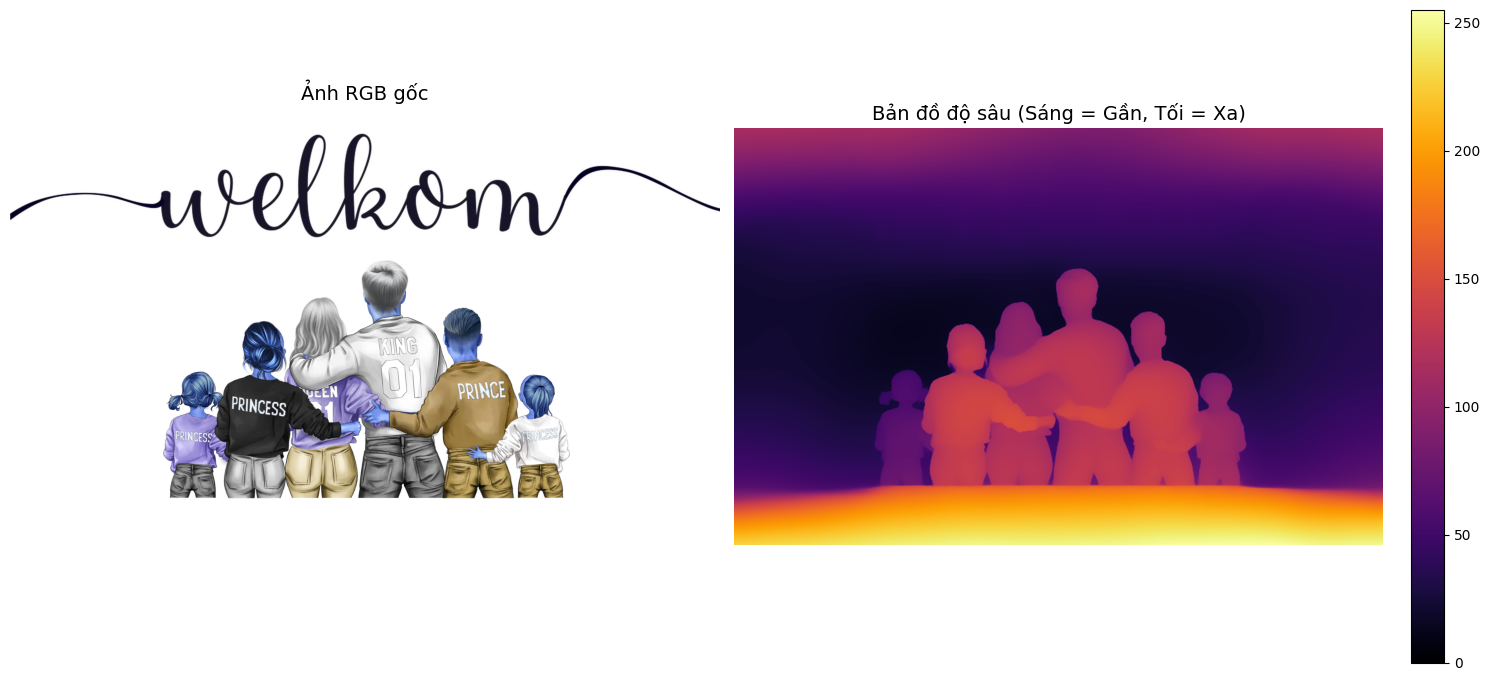

In [12]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from transformers import pipeline

print("Đang tải mô hình Depth Estimation...")
device = 0 if torch.cuda.is_available() else -1 # Tự động dùng GPU nếu có
depth_estimator = pipeline(
    task="depth-estimation", 
    model="depth-anything/Depth-Anything-V2-Large-hf", 
    device=device
)
print("Tải mô hình thành công!")

def estimate_depth_order(image_bgr: np.ndarray, masks: list) -> list:
    """
    Hàm xác định thứ tự chiều sâu của các mask dựa trên Depth Map.
    Trả về danh sách index, từ vật GẦN NHẤT (Nằm trên cùng) đến XA NHẤT (Nằm dưới cùng).
    """
    # 1. Chuyển đổi ảnh OpenCV (BGR) sang chuẩn PIL (RGB) cho mô hình
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(image_rgb)

    # 2. Chạy model để lấy Depth Map
    result = depth_estimator(pil_image)
    
    # Kết quả là một ảnh PIL, chuyển về Numpy array (H, W)
    depth_map = np.array(result["depth"])
    
    # 3. Tính toán độ sâu trung vị (Median Depth) cho từng vật thể
    depth_scores = []
    for idx, mask in enumerate(masks):
        # Đảm bảo mask là dạng boolean
        mask_bool = mask > 0 if mask.dtype != bool else mask
        
        # Trích xuất các pixel độ sâu nằm trong vùng mask của vật thể này
        object_depth_pixels = depth_map[mask_bool]
        
        if len(object_depth_pixels) > 0:
            # Dùng Median (Trung vị) thay vì Mean (Trung bình) để chống nhiễu ở viền mask
            median_depth = np.median(object_depth_pixels)
            depth_scores.append((idx, median_depth))
        else:
            # Nếu mask rỗng, đẩy nó ra xa nhất
            depth_scores.append((idx, 0))
            
    # 4. Sắp xếp thứ tự (Depth càng lớn -> Càng gần -> Nằm trên cùng)
    depth_scores.sort(key=lambda x: x[1], reverse=True)
    
    # Chỉ trích xuất danh sách các index đã sắp xếp
    sorted_indices = [item[0] for item in depth_scores]
    
    return sorted_indices, depth_map

# ==========================================
# 2. CODE TEST VÀ VISUALIZE
# ==========================================
# Giả sử bạn đã có image_np (ảnh BGR) và raw_masks (danh sách mask từ YOLO/SAM)
# image_np = cv2.imread("anh_cua_ban.jpg")
# raw_masks = [mask1, mask2, ...]

sorted_indices, depth_map = estimate_depth_order(image_np, raw_masks)

print(f"Thứ tự chiều sâu (Từ trên xuống dưới): {sorted_indices}")

# Vẽ biểu đồ trực quan
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Hình 1: Ảnh gốc (Chuyển hệ màu để hiển thị matplotlib)
axes[0].set_title("Ảnh RGB gốc", fontsize=14)
axes[0].imshow(cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB))
axes[0].axis('off')

# Hình 2: Depth Map
axes[1].set_title("Bản đồ độ sâu (Sáng = Gần, Tối = Xa)", fontsize=14)
# Dùng colormap 'inferno' hoặc 'magma' để nhìn rõ độ sâu
im = axes[1].imshow(depth_map, cmap='inferno') 
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Test chạy trên gpu 


[INFO] GPU Acceleration (CuPy) Enabled: True

--- BẮT ĐẦU BENCHMARK ---
Đang khởi động CuPy JIT Compiler...
✅ Thời gian GPU thuần (Pure GPU + ROI): 0.23325s
✅ Thời gian CPU (ROI Optimized):        0.17754s
🚀 GPU nhanh hơn CPU khoảng: 0.76 lần


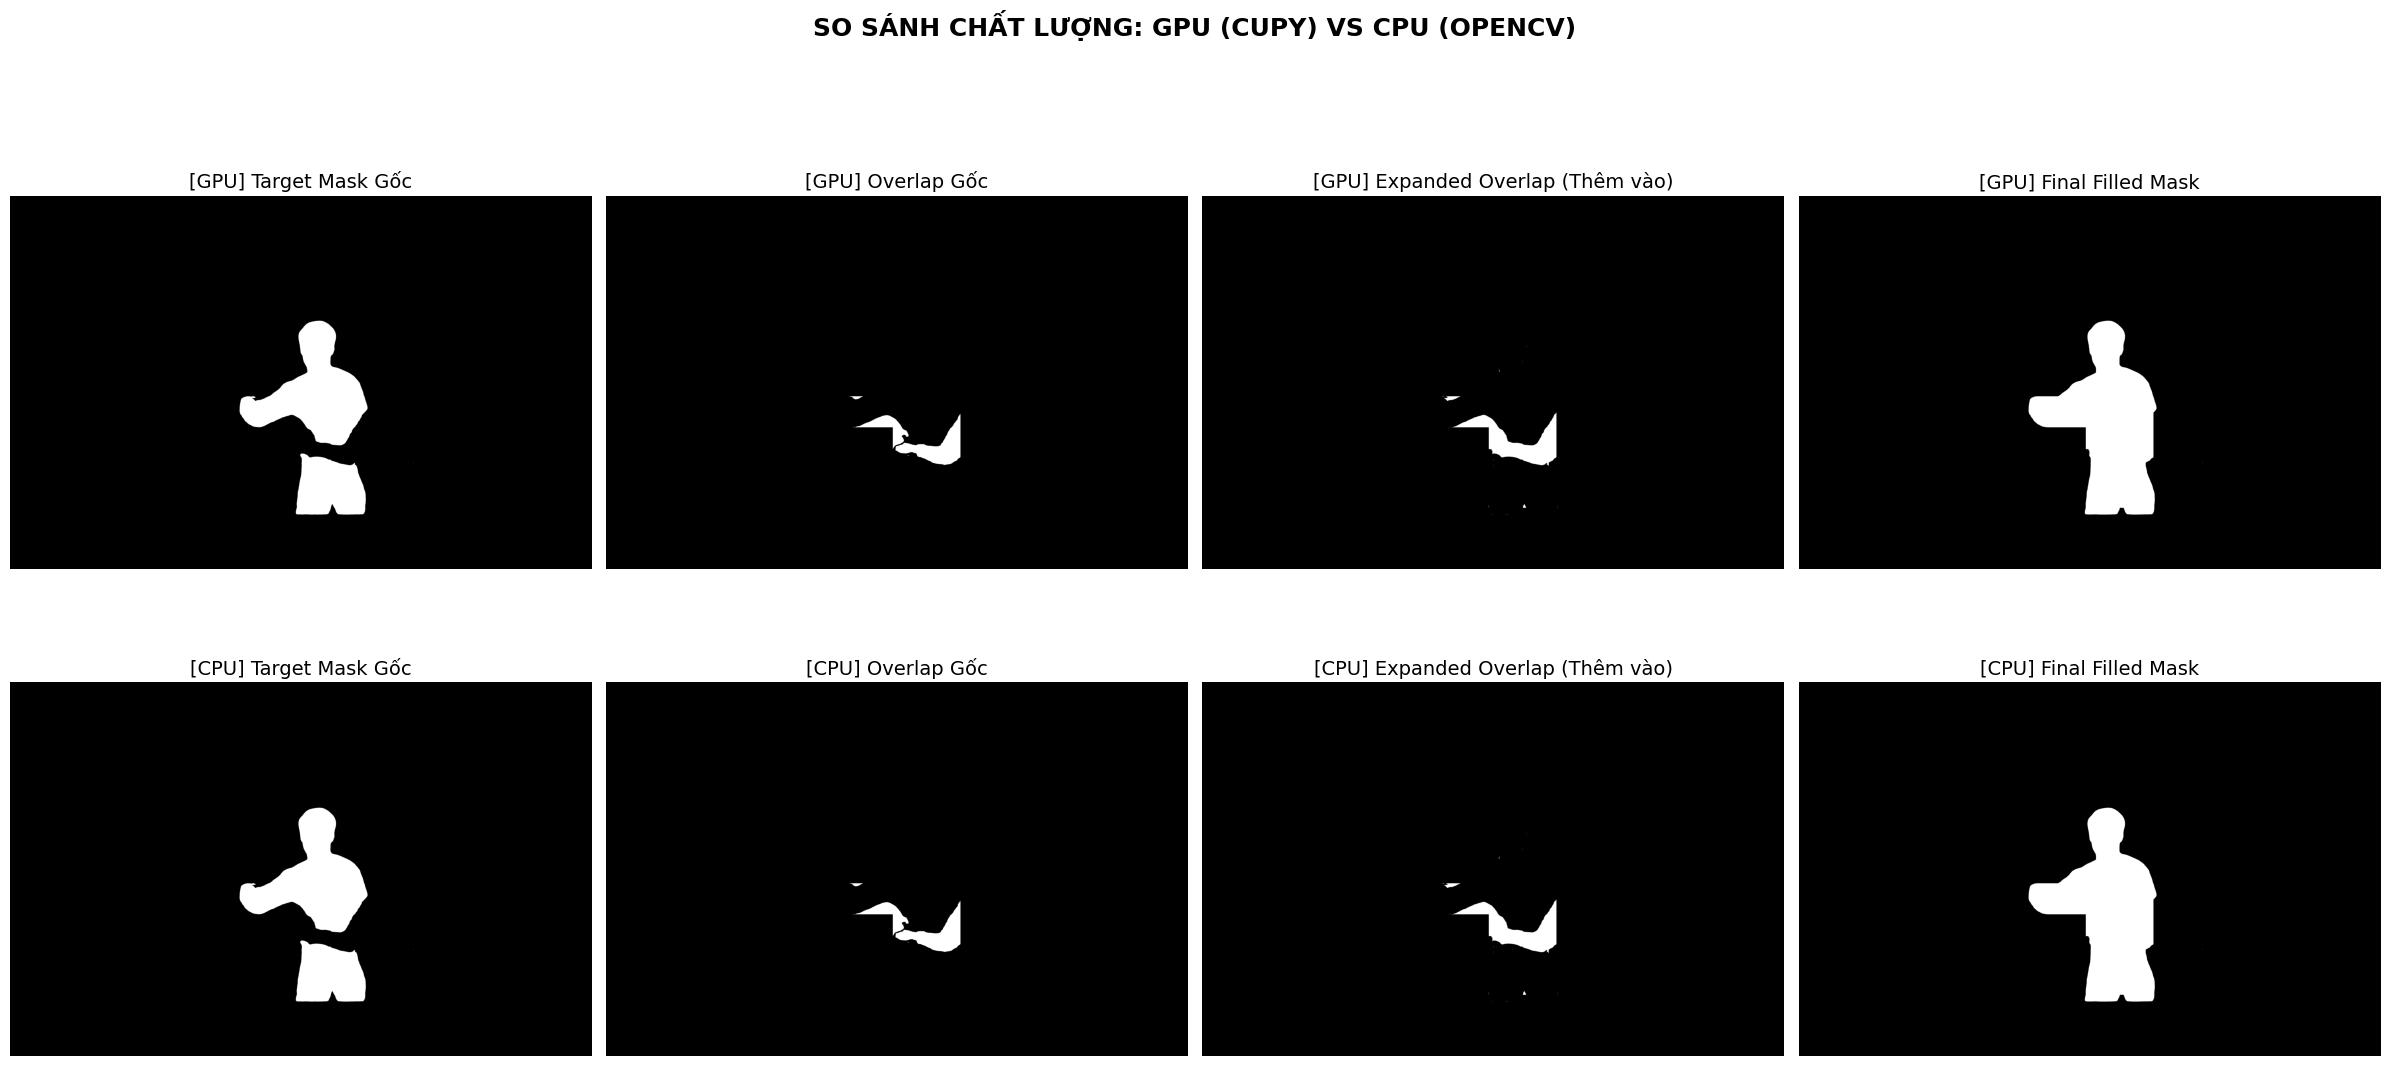

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import importlib.util

HAS_GPU = importlib.util.find_spec('cupy') is not None
if HAS_GPU:
    try:
        import cupy as cp
        from cupyx.scipy.ndimage import binary_dilation, binary_erosion, binary_fill_holes
    except ImportError:
        HAS_GPU = False
print(f"[INFO] GPU Acceleration (CuPy) Enabled: {HAS_GPU}")


def to_u8(m: np.ndarray) -> np.ndarray:
    """Ép kiểu an toàn, chống tràn số và chống làm tròn mất dữ liệu float."""
    if m.dtype == bool: 
        return m.astype(np.uint8) * 255
    return (m * 255).astype(np.uint8) if np.max(m) <= 1 else m.copy().astype(np.uint8)

def _cpu_optimized_path(target_bin: np.ndarray, overlap_bin: np.ndarray, k: int) -> np.ndarray:
    """Đường dẫn CPU: Xử lý trên vùng ROI nhỏ để tiết kiệm RAM và CPU."""
    H, W = target_bin.shape
    combined = cv2.bitwise_or(target_bin, overlap_bin)
    
    ys, xs = np.where(combined > 0)
    if len(ys) == 0:
        return np.zeros_like(target_bin)
        
    pad = k * 2
    y1, y2 = max(0, int(ys.min()) - pad), min(H, int(ys.max()) + pad)
    x1, x2 = max(0, int(xs.min()) - pad), min(W, int(xs.max()) + pad)
    
    roi_combined = combined[y1:y2, x1:x2]
    roi_target   = target_bin[y1:y2, x1:x2]
    rH, rW = roi_combined.shape
    
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))
    dilated = cv2.dilate(roi_combined, kernel)
    
    flood = dilated.copy()
    ff = np.zeros((rH + 2, rW + 2), np.uint8)
    cv2.floodFill(flood, ff, (0, 0), 255)
    dilated_filled = cv2.bitwise_or(dilated, cv2.bitwise_not(flood))
    
    eroded = cv2.erode(dilated_filled, kernel)
    roi_result = cv2.bitwise_or(eroded, roi_combined)
    roi_expanded = cv2.subtract(roi_result, roi_target)
    
    result_full = np.zeros_like(target_bin)
    result_full[y1:y2, x1:x2] = roi_expanded
    return result_full

def _pure_gpu_optimized_path(target_bin: np.ndarray, overlap_bin: np.ndarray, k: int) -> np.ndarray:
    """
    Đường dẫn PURE GPU: 
    - Cắt ROI trước khi đẩy lên GPU để tránh nghẽn cổ chai băng thông PCIe.
    - Dùng 100% thư viện CuPy để không phải copy ngược về CPU giữa chừng.
    """
    import cupy as cp
    from cupyx.scipy.ndimage import binary_dilation, binary_erosion, binary_fill_holes

    H, W = target_bin.shape
    combined = cv2.bitwise_or(target_bin, overlap_bin)

    # 1. Cắt ROI trên CPU 
    ys, xs = np.where(combined > 0)
    if len(ys) == 0:
        return np.zeros_like(target_bin)

    pad = k * 2
    y1, y2 = max(0, int(ys.min()) - pad), min(H, int(ys.max()) + pad)
    x1, x2 = max(0, int(xs.min()) - pad), min(W, int(xs.max()) + pad)

    roi_combined = combined[y1:y2, x1:x2]
    roi_target   = target_bin[y1:y2, x1:x2]

    # 2. Upload phần ảnh nhỏ (ROI) lên GPU
    combined_gpu = cp.asarray(roi_combined > 0)
    target_gpu   = cp.asarray(roi_target > 0)
    struct       = cp.ones((k, k), dtype=bool)

    # 3. Tính toán 100% trên GPU
    dilated_gpu = binary_dilation(combined_gpu, structure=struct, iterations=1)
    filled_gpu  = binary_fill_holes(dilated_gpu)
    eroded_gpu  = binary_erosion(filled_gpu, structure=struct, iterations=1)

    result_gpu   = eroded_gpu | combined_gpu
    expanded_gpu = result_gpu & ~target_gpu

    # 4. Download kết quả về CPU và dán lại vào ảnh gốc
    roi_expanded = (cp.asnumpy(expanded_gpu).astype(np.uint8) * 255)
    result_full = np.zeros_like(target_bin)
    result_full[y1:y2, x1:x2] = roi_expanded

    return result_full

def get_expanded_overlap_fast(mask: np.ndarray, overlap: np.ndarray, crack_thickness: int = 25, force_cpu: bool = False) -> np.ndarray:
    """Hàm bọc ngoài, tự động chọn luồng thực thi."""
    target_u8  = cv2.threshold(to_u8(mask), 127, 255, cv2.THRESH_BINARY)[1]
    overlap_u8 = cv2.threshold(to_u8(overlap), 127, 255, cv2.THRESH_BINARY)[1]

    if crack_thickness is None:
        ys, xs = np.where(overlap_u8 > 0)
        if len(ys) > 0:
            oh, ow = int(ys.max()) - int(ys.min()), int(xs.max()) - int(xs.min())
            crack_thickness = max(7, int(min(oh, ow) * 0.15))
        else:
            crack_thickness = 7

    k = crack_thickness + (1 - crack_thickness % 2) # Đảm bảo k là số lẻ

    if HAS_GPU and not force_cpu:
        return _pure_gpu_optimized_path(target_u8, overlap_u8, k)
    else:
        return _cpu_optimized_path(target_u8, overlap_u8, k)


# ==========================================
# 2. BENCHMARK & VISUALIZE
# ==========================================
crack_size = 40

print("\n--- BẮT ĐẦU BENCHMARK ---")

# A. Chạy GPU
expanded_gpu = None
if HAS_GPU:
    # BƯỚC QUAN TRỌNG: Warm-up GPU (Biên dịch mã JIT lần đầu)
    print("Đang khởi động CuPy JIT Compiler...")
    _ = get_expanded_overlap_fast(target_mask, combined_safe_overlap, crack_thickness=crack_size, force_cpu=False)
    
    # Đo thời gian GPU thực tế
    start_time = time.time()
    expanded_gpu = get_expanded_overlap_fast(target_mask, combined_safe_overlap, crack_thickness=crack_size, force_cpu=False)
    gpu_time = time.time() - start_time
    print(f"✅ Thời gian GPU thuần (Pure GPU + ROI): {gpu_time:.5f}s")
else:
    print("❌ Không có GPU, bỏ qua test GPU.")

# B. Chạy CPU
start_time = time.time()
expanded_cpu = get_expanded_overlap_fast(target_mask, combined_safe_overlap, crack_thickness=crack_size, force_cpu=True)
cpu_time = time.time() - start_time
print(f"✅ Thời gian CPU (ROI Optimized):        {cpu_time:.5f}s")

if HAS_GPU:
    speedup = cpu_time / gpu_time if gpu_time > 0 else 0
    print(f"🚀 GPU nhanh hơn CPU khoảng: {speedup:.2f} lần")


# C. Trực quan hóa đối chiếu
target_u8_vis = to_u8(target_mask)
overlap_u8_vis = to_u8(combined_safe_overlap)

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
fig.suptitle("SO SÁNH CHẤT LƯỢNG: GPU (CUPY) VS CPU (OPENCV)", fontsize=18, fontweight='bold')

# HÀNG 1: KẾT QUẢ GPU
if HAS_GPU:
    final_filled_gpu = cv2.bitwise_or(target_u8_vis, expanded_gpu)
    axes[0, 0].set_title("[GPU] Target Mask Gốc", fontsize=14)
    axes[0, 0].imshow(target_u8_vis, cmap='gray')
    
    axes[0, 1].set_title("[GPU] Overlap Gốc", fontsize=14)
    axes[0, 1].imshow(overlap_u8_vis, cmap='gray')
    
    axes[0, 2].set_title(f"[GPU] Expanded Overlap (Thêm vào)", fontsize=14)
    axes[0, 2].imshow(expanded_gpu, cmap='gray')
    
    axes[0, 3].set_title("[GPU] Final Filled Mask", fontsize=14)
    axes[0, 3].imshow(final_filled_gpu, cmap='gray')
else:
    for ax in axes[0]: ax.text(0.5, 0.5, 'NO GPU', ha='center', va='center', fontsize=20)

# HÀNG 2: KẾT QUẢ CPU
final_filled_cpu = cv2.bitwise_or(target_u8_vis, expanded_cpu)
axes[1, 0].set_title("[CPU] Target Mask Gốc", fontsize=14)
axes[1, 0].imshow(target_u8_vis, cmap='gray')

axes[1, 1].set_title("[CPU] Overlap Gốc", fontsize=14)
axes[1, 1].imshow(overlap_u8_vis, cmap='gray')

axes[1, 2].set_title(f"[CPU] Expanded Overlap (Thêm vào)", fontsize=14)
axes[1, 2].imshow(expanded_cpu, cmap='gray')

axes[1, 3].set_title("[CPU] Final Filled Mask", fontsize=14)
axes[1, 3].imshow(final_filled_cpu, cmap='gray')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

--- BẮT ĐẦU ĐO HIỆU NĂNG (Chạy 50 lần) ---
Hàm cũ (Full Image):  0.10086 giây / lần
Hàm mới (ROI Crop):   0.06393 giây / lần
🚀 Tốc độ tăng tốc: Nhanh hơn 1.58 lần!
✅ Kết quả Pixel giống nhau 100%: True


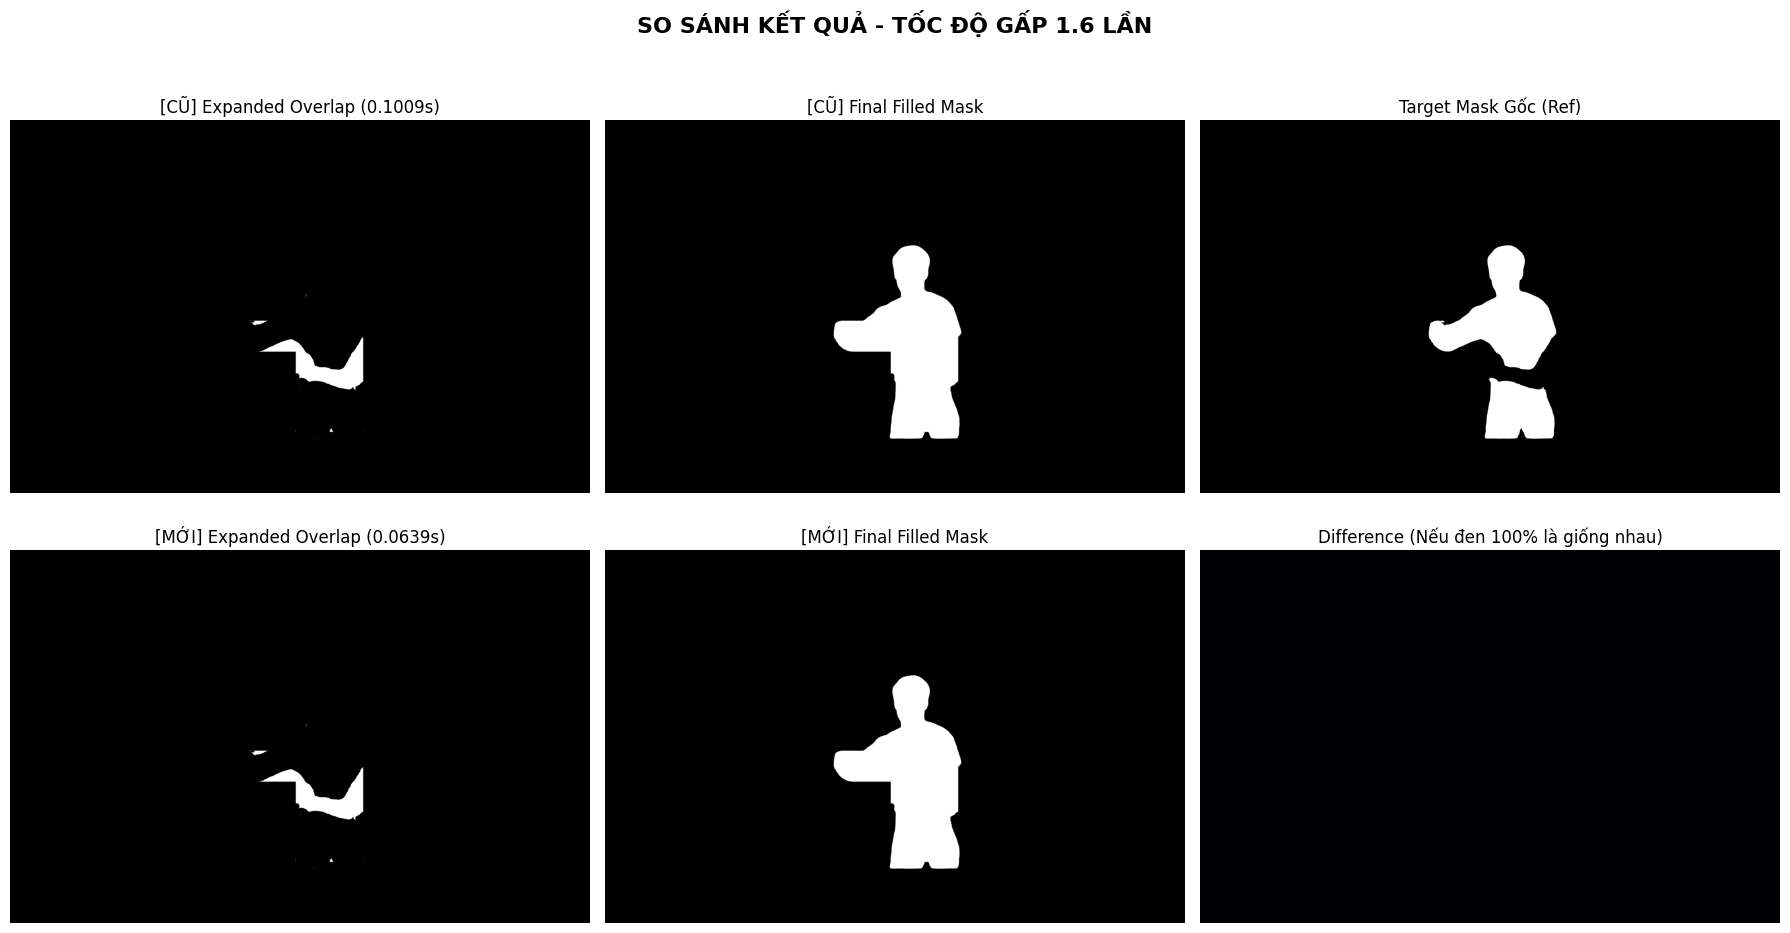

In [25]:
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt

# ==========================================
# 1. HÀM CŨ (ORIGINAL)
# ==========================================
def get_expanded_overlap_old(mask: np.ndarray, overlap: np.ndarray, crack_thickness: int = 25) -> np.ndarray:
    def to_u8(m):
        if m.dtype == bool: return m.astype(np.uint8) * 255
        return (m * 255).astype(np.uint8) if np.max(m) <= 1 else m.copy().astype(np.uint8)

    _, target_bin  = cv2.threshold(to_u8(mask),    127, 255, cv2.THRESH_BINARY)
    _, overlap_bin = cv2.threshold(to_u8(overlap), 127, 255, cv2.THRESH_BINARY)
    
    if crack_thickness is None:
        ys, xs = np.where(overlap_bin > 0)
        if len(ys) > 0:
            oh = int(ys.max()) - int(ys.min())
            ow = int(xs.max()) - int(xs.min())
            crack_thickness = max(7, int(min(oh, ow) * 0.15))
        else:
            crack_thickness = 7
    
    combined = cv2.bitwise_or(target_bin, overlap_bin)
    H, W = combined.shape

    k = crack_thickness + (1 - crack_thickness % 2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))

    dilated = cv2.dilate(combined, kernel, iterations=1)

    flood = dilated.copy()
    ff = np.zeros((H + 2, W + 2), np.uint8)
    cv2.floodFill(flood, ff, (0, 0), 255)
    dilated_filled = cv2.bitwise_or(dilated, cv2.bitwise_not(flood))

    eroded = cv2.erode(dilated_filled, kernel, iterations=1)
    result = cv2.bitwise_or(eroded, combined)

    expanded_overlap = cv2.subtract(result, target_bin)
    return expanded_overlap

# ==========================================
# 2. HÀM MỚI (FAST ROI-OPTIMIZED)
# ==========================================
def get_expanded_overlap_fast(mask: np.ndarray, overlap: np.ndarray, crack_thickness: int = 25) -> np.ndarray:
    def to_u8(m):
        if m.dtype == bool: return m.astype(np.uint8) * 255
        return (m * 255).astype(np.uint8) if np.max(m) <= 1 else m.copy().astype(np.uint8)

    # 1. Ép kiểu an toàn
    _, target_bin  = cv2.threshold(to_u8(mask), 127, 255, cv2.THRESH_BINARY)
    _, overlap_bin = cv2.threshold(to_u8(overlap), 127, 255, cv2.THRESH_BINARY)

    # 2. Tính kích thước kernel
    if crack_thickness is None:
        coords_overlap = cv2.findNonZero(overlap_bin)
        if coords_overlap is not None:
            _, _, w_ov, h_ov = cv2.boundingRect(coords_overlap)
            crack_thickness = max(7, int(min(h_ov, w_ov) * 0.15))
        else:
            crack_thickness = 7
            
    k = crack_thickness + (1 - crack_thickness % 2)

    # 3. Gộp mask và Tìm ROI (Region of Interest)
    combined = cv2.bitwise_or(target_bin, overlap_bin)
    coords_combined = cv2.findNonZero(combined)
    
    if coords_combined is None:
        return np.zeros_like(target_bin)
        
    x, y, w, h = cv2.boundingRect(coords_combined)
    H, W = combined.shape
    
    pad = k * 2
    x1, y1 = max(0, x - pad), max(0, y - pad)
    x2, y2 = min(W, x + w + pad), min(H, y + h + pad)

    # Trích xuất ROI
    roi_combined = combined[y1:y2, x1:x2]
    roi_target   = target_bin[y1:y2, x1:x2]
    rH, rW = roi_combined.shape

    # 4. Thực thi hình thái học CỤC BỘ
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, k))
    
    dilated = cv2.dilate(roi_combined, kernel)
    flood = dilated.copy()
    ff = np.zeros((rH + 2, rW + 2), np.uint8)
    cv2.floodFill(flood, ff, (0, 0), 255)
    
    dilated_filled = cv2.bitwise_or(dilated, cv2.bitwise_not(flood))
    eroded = cv2.erode(dilated_filled, kernel)
    
    roi_result = cv2.bitwise_or(eroded, roi_combined)
    roi_expanded = cv2.subtract(roi_result, roi_target)

    # 5. Dán ROI về ảnh full-size
    result_full = np.zeros_like(target_bin)
    result_full[y1:y2, x1:x2] = roi_expanded

    return result_full

# ==========================================
# 3. BENCHMARK & VISUALIZE
# ==========================================
# Lưu ý: Các biến target_mask và combined_safe_overlap phải có sẵn trong môi trường của bạn
crack_size = 40
num_iterations = 50 # Chạy nhiều lần để lấy trung bình

print(f"--- BẮT ĐẦU ĐO HIỆU NĂNG (Chạy {num_iterations} lần) ---")

# Đo thời gian hàm cũ
start_old = time.perf_counter()
for _ in range(num_iterations):
    res_old = get_expanded_overlap_old(target_mask, combined_safe_overlap, crack_thickness=crack_size)
time_old = (time.perf_counter() - start_old) / num_iterations
print(f"Hàm cũ (Full Image):  {time_old:.5f} giây / lần")

# Đo thời gian hàm mới
start_fast = time.perf_counter()
for _ in range(num_iterations):
    res_fast = get_expanded_overlap_fast(target_mask, combined_safe_overlap, crack_thickness=crack_size)
time_fast = (time.perf_counter() - start_fast) / num_iterations
print(f"Hàm mới (ROI Crop):   {time_fast:.5f} giây / lần")

# Tính tỷ lệ tốc độ
speedup = time_old / time_fast if time_fast > 0 else 0
print(f"🚀 Tốc độ tăng tốc: Nhanh hơn {speedup:.2f} lần!")

# Kiểm tra tính toàn vẹn dữ liệu
is_identical = np.array_equal(res_old, res_fast)
print(f"✅ Kết quả Pixel giống nhau 100%: {is_identical}")

# --- Trực quan hóa ---
def to_u8_vis(m):
    if m.dtype == bool: return m.astype(np.uint8) * 255
    return (m * 255).astype(np.uint8) if np.max(m) <= 1 else m.copy().astype(np.uint8)

target_vis = to_u8_vis(target_mask)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f"SO SÁNH KẾT QUẢ - TỐC ĐỘ GẤP {speedup:.1f} LẦN", fontsize=16, fontweight='bold')

# Hàng 1: Hàm Cũ
final_old = cv2.bitwise_or(target_vis, res_old)
axes[0, 0].set_title(f"[CŨ] Expanded Overlap ({time_old:.4f}s)", fontsize=12)
axes[0, 0].imshow(res_old, cmap='gray')

axes[0, 1].set_title("[CŨ] Final Filled Mask", fontsize=12)
axes[0, 1].imshow(final_old, cmap='gray')

axes[0, 2].set_title("Target Mask Gốc (Ref)", fontsize=12)
axes[0, 2].imshow(target_vis, cmap='gray')

# Hàng 2: Hàm Mới
final_fast = cv2.bitwise_or(target_vis, res_fast)
axes[1, 0].set_title(f"[MỚI] Expanded Overlap ({time_fast:.4f}s)", fontsize=12)
axes[1, 0].imshow(res_fast, cmap='gray')

axes[1, 1].set_title("[MỚI] Final Filled Mask", fontsize=12)
axes[1, 1].imshow(final_fast, cmap='gray')

# Hiển thị độ lệch (Difference map) để chứng minh chúng giống nhau
diff_map = cv2.absdiff(res_old, res_fast)
axes[1, 2].set_title("Difference (Nếu đen 100% là giống nhau)", fontsize=12)
axes[1, 2].imshow(diff_map, cmap='magma')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [28]:
import cv2
import numpy as np

try:
    import cupy as cp
    from cupyx.scipy.ndimage import binary_dilation, binary_erosion
    HAS_GPU = True
except ImportError:
    HAS_GPU = False


def calculate_multi_occluder_overlap(
    target_mask: np.ndarray,
    bbox_target: list,
    occluder_masks: list,
    bbox_occluders: list
):
    def safe_to_u8(m: np.ndarray) -> np.ndarray:
        if m.dtype == bool:
            return m.astype(np.uint8) * 255
        return (m * 255).astype(np.uint8) if np.max(m) <= 1 else m.copy().astype(np.uint8)

    target_u8 = safe_to_u8(target_mask)
    H, W = target_u8.shape

    if HAS_GPU:
        return _calculate_gpu(target_u8, bbox_target, occluder_masks, bbox_occluders, H, W, safe_to_u8)
    else:
        return _calculate_cpu(target_u8, bbox_target, occluder_masks, bbox_occluders, H, W, safe_to_u8)


# ─────────────────────────────────────────────────────────────────────────────
# GPU PATH
# ─────────────────────────────────────────────────────────────────────────────
def _calculate_gpu(target_u8, bbox_target, occluder_masks, bbox_occluders, H, W, safe_to_u8):

    x, y, w, h = bbox_target
    close_k_size = max(15, int(min(w, h) * 0.6))
    pad = close_k_size // 2

    x1 = max(0, x - pad);  x2 = min(W, x + w + pad)
    y1 = max(0, y - pad);  y2 = min(H, y + h + pad)

    # ── Closing trên GPU ─────────────────────────────────────────────────
    roi_gpu = cp.asarray(target_u8[y1:y2, x1:x2] > 0)
    struct  = cp.ones((close_k_size, close_k_size), dtype=bool)

    closed_roi_gpu = binary_dilation(roi_gpu, structure=struct)
    closed_roi_gpu = binary_erosion(closed_roi_gpu, structure=struct)   # = MORPH_CLOSE

    predicted_full_gpu = cp.zeros((H, W), dtype=bool)
    predicted_full_gpu[y1:y2, x1:x2] = closed_roi_gpu

    # ── Vectorize tất cả occluder masks lên GPU 1 lần ────────────────────
    # Stack thành (N, H, W) để xử lý song song
    n = len(occluder_masks)

    occ_stack   = cp.zeros((n, H, W), dtype=bool)  # (N,H,W) occluder masks
    zone_stack  = cp.zeros((n, H, W), dtype=bool)  # (N,H,W) safe zones

    for i, (occ_mask, occ_bbox) in enumerate(zip(occluder_masks, bbox_occluders)):
        occ_u8 = safe_to_u8(occ_mask)
        occ_stack[i] = cp.asarray(occ_u8 > 0)

        intersect = _get_bbox_intersection(bbox_target, occ_bbox)
        if intersect:
            ix, iy, iw, ih = intersect
            zone_stack[i, iy:iy+ih, ix:ix+iw] = True

    # ── Tính overlap song song trên toàn stack ────────────────────────────
    # raw_overlap[i]  = predicted_full & occ_stack[i]
    # safe_overlap[i] = raw_overlap[i] & zone_stack[i]
    raw_overlap_stack  = predicted_full_gpu[None, :, :] & occ_stack   # broadcast (N,H,W)
    safe_overlap_stack = raw_overlap_stack & zone_stack

    # Reduce: OR toàn bộ occluder → (H,W)
    combined_safe_zone_gpu    = cp.any(zone_stack,         axis=0)
    combined_safe_overlap_gpu = cp.any(safe_overlap_stack, axis=0)

    # ── Download về CPU ───────────────────────────────────────────────────
    predicted_full_target  = (cp.asnumpy(predicted_full_gpu).astype(np.uint8)      * 255)
    combined_safe_zone     = (cp.asnumpy(combined_safe_zone_gpu).astype(np.uint8)  * 255)
    combined_safe_overlap  = (cp.asnumpy(combined_safe_overlap_gpu).astype(np.uint8) * 255)

    # ── get_expanded_overlap + final mask ────────────────────────────────
    expanded_overlap  = get_expanded_overlap(target_u8, combined_safe_overlap, crack_thickness=40)
    final_filled_mask = cv2.bitwise_or(target_u8, expanded_overlap)

    return predicted_full_target, combined_safe_zone, combined_safe_overlap, final_filled_mask


# ─────────────────────────────────────────────────────────────────────────────
# CPU PATH (tối ưu ROI, tránh copy thừa)
# ─────────────────────────────────────────────────────────────────────────────
def _calculate_cpu(target_u8, bbox_target, occluder_masks, bbox_occluders, H, W, safe_to_u8):

    x, y, w, h = bbox_target
    close_k_size = max(15, int(min(w, h) * 0.6))
    pad = close_k_size // 2

    x1 = max(0, x - pad);  x2 = min(W, x + w + pad)
    y1 = max(0, y - pad);  y2 = min(H, y + h + pad)

    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (close_k_size, close_k_size))
    closed_roi   = cv2.morphologyEx(target_u8[y1:y2, x1:x2], cv2.MORPH_CLOSE, kernel_close)

    predicted_full_target = np.zeros_like(target_u8)
    predicted_full_target[y1:y2, x1:x2] = closed_roi

    # Dùng bool array thay uint8 → bitwise ops nhanh hơn
    predicted_bool = predicted_full_target > 0

    combined_safe_overlap = np.zeros((H, W), dtype=bool)
    combined_safe_zone    = np.zeros((H, W), dtype=bool)

    for occ_mask, occ_bbox in zip(occluder_masks, bbox_occluders):
        occ_bool = safe_to_u8(occ_mask) > 0

        intersect = _get_bbox_intersection(bbox_target, occ_bbox)
        if not intersect:
            continue

        ix, iy, iw, ih = intersect

        # Chỉ xử lý trong ROI intersection thay vì full array
        pred_roi = predicted_bool[iy:iy+ih, ix:ix+iw]
        occ_roi  = occ_bool[iy:iy+ih, ix:ix+iw]

        safe_overlap_roi = pred_roi & occ_roi

        combined_safe_zone[iy:iy+ih, ix:ix+iw]    = True
        combined_safe_overlap[iy:iy+ih, ix:ix+iw] |= safe_overlap_roi

    combined_safe_zone    = (combined_safe_zone.astype(np.uint8)    * 255)
    combined_safe_overlap = (combined_safe_overlap.astype(np.uint8) * 255)
    predicted_full_target = predicted_full_target

    expanded_overlap  = get_expanded_overlap(target_u8, combined_safe_overlap, crack_thickness=40)
    final_filled_mask = cv2.bitwise_or(target_u8, expanded_overlap)

    return predicted_full_target, combined_safe_zone, combined_safe_overlap, final_filled_mask

--- 🚀 BẮT ĐẦU BENCHMARK CPU vs GPU ---

⏳ Đang đo tốc độ CPU...
✅ Tốc độ CPU (Trung bình): 0.57787 giây/lần

🔥 Đang Warm-up GPU (Biên dịch CuPy JIT lần đầu)...
⏳ Đang đo tốc độ GPU...
✅ Tốc độ GPU (Trung bình): 7.54701 giây/lần
🏆 KẾT LUẬN: CPU nhanh hơn GPU 13.06 lần!
🔍 Kiểm tra chéo: Kết quả Pixel giữa CPU và GPU giống nhau 100% -> False

🎨 Đang hiển thị kết quả từ luồng CPU...


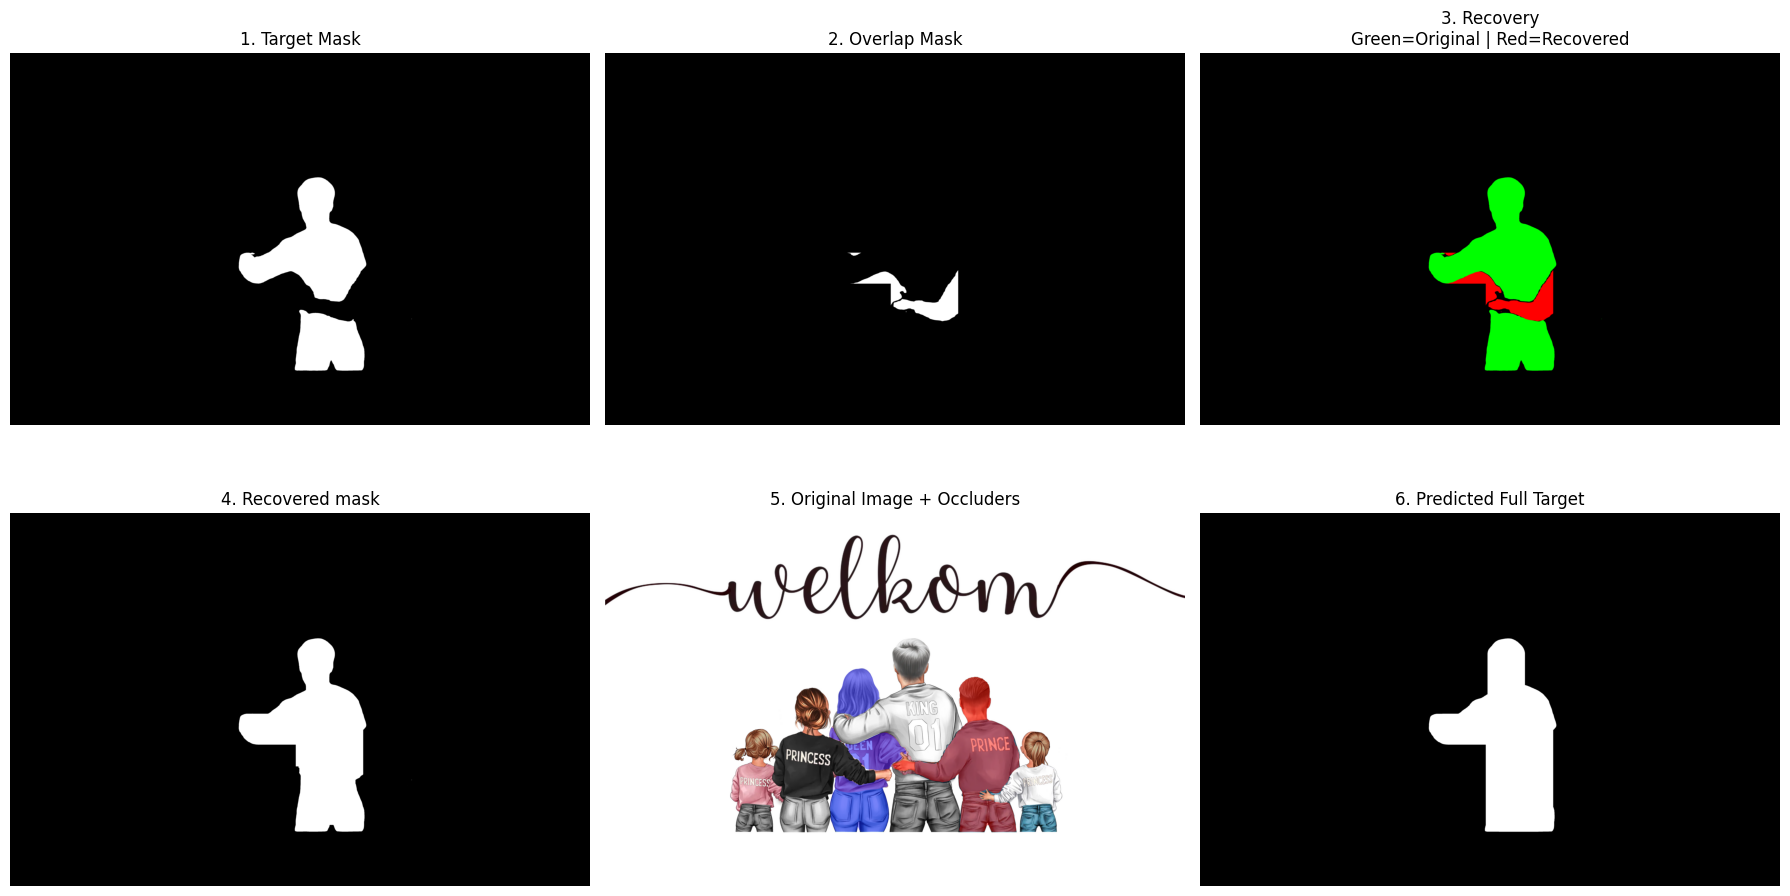


🎨 Đang hiển thị kết quả từ luồng GPU...


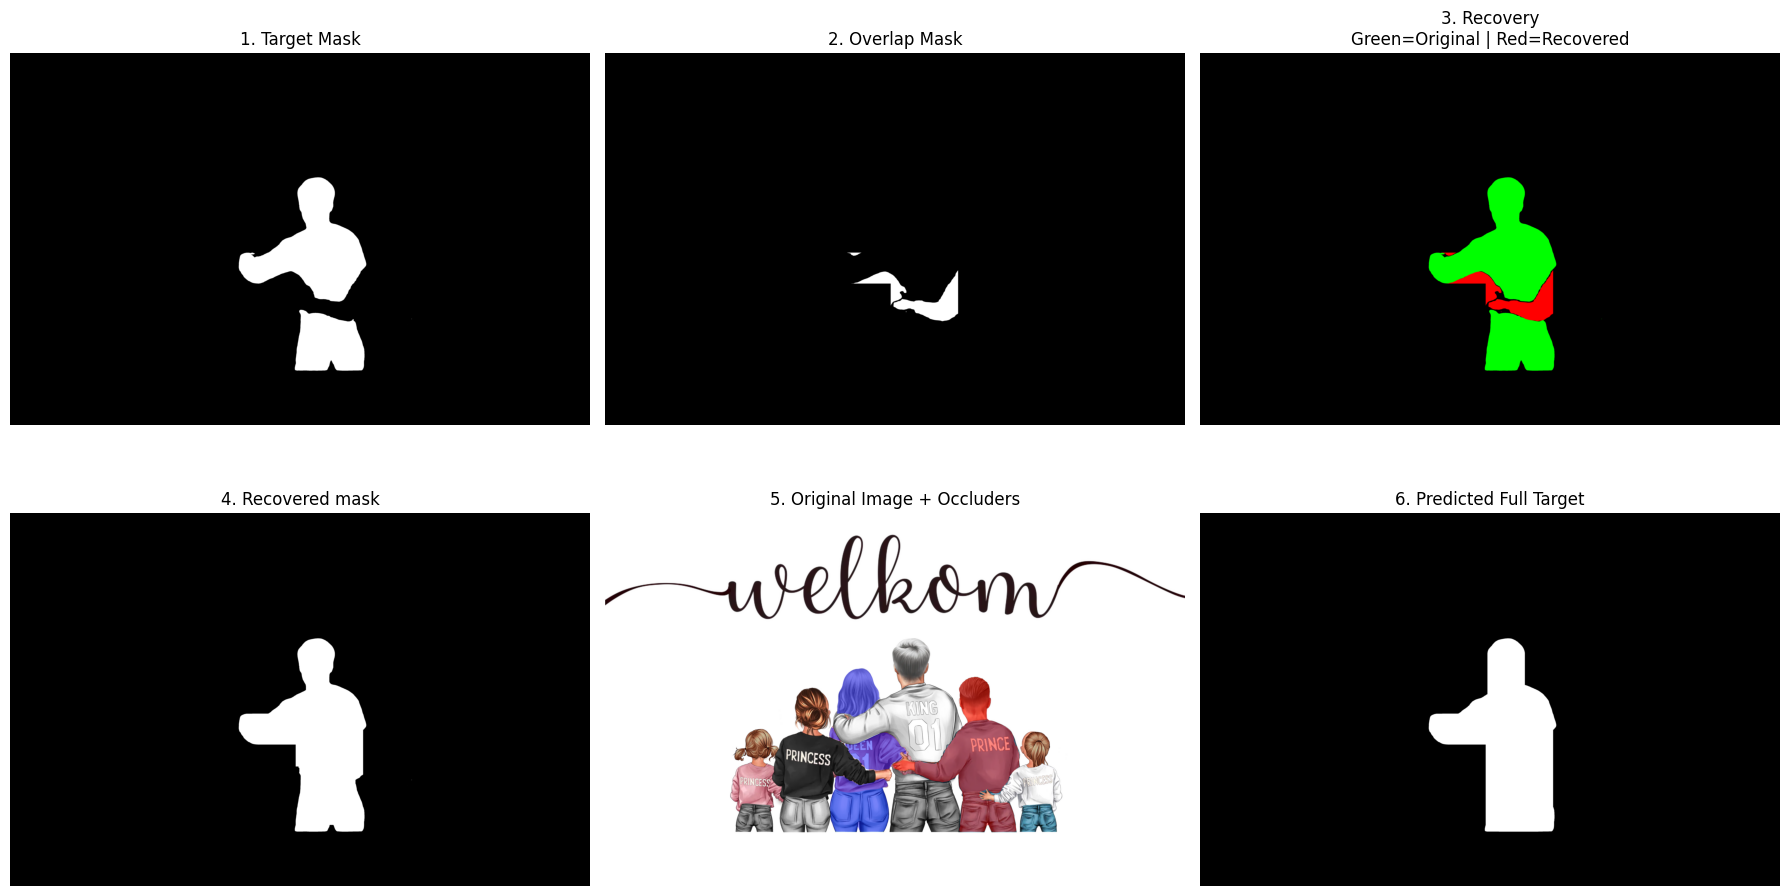

In [29]:
import time
import numpy as np

# ==========================================
# CÀI ĐẶT THÔNG SỐ BENCHMARK
# ==========================================
num_iterations = 20 # Chạy 20 lần để lấy thời gian trung bình (loại bỏ nhiễu hệ điều hành)

print("--- 🚀 BẮT ĐẦU BENCHMARK CPU vs GPU ---")

# Chuẩn bị dữ liệu đầu vào chung
def safe_to_u8_test(m: np.ndarray) -> np.ndarray:
    if m.dtype == bool:
        return m.astype(np.uint8) * 255
    return (m * 255).astype(np.uint8) if np.max(m) <= 1 else m.copy().astype(np.uint8)

target_u8_test = safe_to_u8_test(target_mask)
H, W = target_u8_test.shape

# ==========================================
# 1. ĐO TỐC ĐỘ CPU
# ==========================================
print("\n⏳ Đang đo tốc độ CPU...")
start_cpu = time.perf_counter()
for _ in range(num_iterations):
    res_cpu = _calculate_cpu(target_u8_test, bbox_target, occluder_masks, bbox_occluders, H, W, safe_to_u8_test)
time_cpu = (time.perf_counter() - start_cpu) / num_iterations
print(f"✅ Tốc độ CPU (Trung bình): {time_cpu:.5f} giây/lần")

# ==========================================
# 2. ĐO TỐC ĐỘ GPU & SO SÁNH
# ==========================================
res_gpu = None
if HAS_GPU:
    print("\n🔥 Đang Warm-up GPU (Biên dịch CuPy JIT lần đầu)...")
    _ = _calculate_gpu(target_u8_test, bbox_target, occluder_masks, bbox_occluders, H, W, safe_to_u8_test)

    print("⏳ Đang đo tốc độ GPU...")
    start_gpu = time.perf_counter()
    for _ in range(num_iterations):
        res_gpu = _calculate_gpu(target_u8_test, bbox_target, occluder_masks, bbox_occluders, H, W, safe_to_u8_test)
    time_gpu = (time.perf_counter() - start_gpu) / num_iterations
    print(f"✅ Tốc độ GPU (Trung bình): {time_gpu:.5f} giây/lần")

    # Đánh giá hiệu năng
    if time_gpu > 0:
        speedup = time_cpu / time_gpu
        if speedup > 1:
            print(f"🏆 KẾT LUẬN: GPU nhanh hơn CPU {speedup:.2f} lần!")
        else:
            print(f"🏆 KẾT LUẬN: CPU nhanh hơn GPU {1/speedup:.2f} lần!")
            
    # Kiểm tra tính toàn vẹn (So sánh 4 outputs: predicted, zone, overlap, final_filled)
    is_identical = True
    for i in range(4):
        if not np.array_equal(res_cpu[i], res_gpu[i]):
            is_identical = False
            break
    print(f"🔍 Kiểm tra chéo: Kết quả Pixel giữa CPU và GPU giống nhau 100% -> {is_identical}")
else:
    print("\n❌ Không tìm thấy GPU (CuPy). Bỏ qua benchmark GPU.")

# ==========================================
# 3. TRỰC QUAN HÓA (VISUALIZE)
# ==========================================
print("\n🎨 Đang hiển thị kết quả từ luồng CPU...")
pred_cpu, zone_cpu, overlap_cpu, final_cpu = res_cpu
visualize_amodal_recovery_multi(
    image_np=image_np,
    target_mask=target_mask,
    final_filled_mask=final_cpu,
    predicted_full_target=pred_cpu,
    occluder_masks=occluder_masks,
    overlap_mask=overlap_cpu
)

if HAS_GPU:
    print("\n🎨 Đang hiển thị kết quả từ luồng GPU...")
    pred_gpu, zone_gpu, overlap_gpu, final_gpu = res_gpu
    visualize_amodal_recovery_multi(
        image_np=image_np,
        target_mask=target_mask,
        final_filled_mask=final_gpu,
        predicted_full_target=pred_gpu,
        occluder_masks=occluder_masks,
        overlap_mask=overlap_gpu
    )

In [32]:
import cv2
import numpy as np

def calculate_multi_occluder_overlap_fast(
    target_mask: np.ndarray,
    bbox_target: list,
    occluder_masks: list,
    bbox_occluders: list
):
    """
    Phiên bản TỐI ƯU 100% CPU - Bỏ hoàn toàn GPU.
    Tốc độ cực nhanh nhờ kỹ thuật cắt ROI và tính toán trên mảng Boolean.
    """
    # 1. Hàm ép kiểu an toàn cục bộ
    def safe_to_u8(m: np.ndarray) -> np.ndarray:
        if m.dtype == bool:
            return m.astype(np.uint8) * 255
        return (m * 255).astype(np.uint8) if np.max(m) <= 1 else m.copy().astype(np.uint8)

    target_u8 = safe_to_u8(target_mask)
    H, W = target_u8.shape

    # ==========================================
    # BƯỚC 1: DỰ ĐOÁN HÌNH DÁNG (CHỈ CHẠY TRÊN ROI)
    # ==========================================
    x, y, w, h = bbox_target
    close_k_size = max(15, int(min(w, h) * 0.6))
    pad = close_k_size // 2

    # Lấy tọa độ ROI có chứa padding để không bị lẹm viền
    x1 = max(0, x - pad);  x2 = min(W, x + w + pad)
    y1 = max(0, y - pad);  y2 = min(H, y + h + pad)

    kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (close_k_size, close_k_size))
    
    # Chỉ Close trên cái hình chữ nhật bé xíu
    closed_roi = cv2.morphologyEx(target_u8[y1:y2, x1:x2], cv2.MORPH_CLOSE, kernel_close)

    # Đưa kết quả về khung ảnh to
    predicted_full_target = np.zeros_like(target_u8)
    predicted_full_target[y1:y2, x1:x2] = closed_roi

    # Đưa target về dạng Boolean (True/False) để tăng tốc độ tính toán phần giao nhau
    predicted_bool = predicted_full_target > 0

    # ==========================================
    # BƯỚC 2: TÌM VÙNG BỊ CHE TỪ NHIỀU VẬT CẢN
    # ==========================================
    # Dùng mảng Boolean để tiết kiệm RAM và tăng tốc toán tử
    combined_safe_overlap = np.zeros((H, W), dtype=bool)
    combined_safe_zone    = np.zeros((H, W), dtype=bool)

    for occ_mask, occ_bbox in zip(occluder_masks, bbox_occluders):
        
        # Lọc thô siêu tốc: Nếu BBox không chạm nhau, bỏ qua ngay!
        intersect = _get_bbox_intersection(bbox_target, occ_bbox)
        if not intersect:
            continue

        ix, iy, iw, ih = intersect

        # Chỉ đưa mask vật cản về dạng bool
        occ_bool = safe_to_u8(occ_mask) > 0

        # KỸ THUẬT QUAN TRỌNG: Chỉ trích xuất đúng cái hũm giao nhau (Intersection ROI)
        pred_roi = predicted_bool[iy:iy+ih, ix:ix+iw]
        occ_roi  = occ_bool[iy:iy+ih, ix:ix+iw]

        # Tính overlap siêu nhanh bằng toán tử AND bitwise (&)
        safe_overlap_roi = pred_roi & occ_roi

        # Cập nhật kết quả vào mảng tổng bằng toán tử OR (|=)
        combined_safe_zone[iy:iy+ih, ix:ix+iw] = True
        combined_safe_overlap[iy:iy+ih, ix:ix+iw] |= safe_overlap_roi

    # Chuyển đổi lại thành chuẩn ảnh 8-bit (0 và 255) cho OpenCV
    combined_safe_zone_u8    = (combined_safe_zone.astype(np.uint8) * 255)
    combined_safe_overlap_u8 = (combined_safe_overlap.astype(np.uint8) * 255)

    # ==========================================
    # BƯỚC 3: LẤP KÍN LỖ HỔNG & TẠO MASK CUỐI
    # ==========================================
    # Gọi hàm CPU siêu tốc get_expanded_overlap mà chúng ta đã làm ở bước trước
    expanded_overlap = get_expanded_overlap(target_u8, combined_safe_overlap_u8, crack_thickness=40)
    
    # Cộng phần "thịt" vừa vá vào mask gốc
    final_filled_mask = cv2.bitwise_or(target_u8, expanded_overlap)

    return predicted_full_target, combined_safe_zone_u8, combined_safe_overlap_u8, final_filled_mask

--- 🚀 BẮT ĐẦU BENCHMARK: HÀM CŨ vs HÀM FAST ---
🐢 Tốc độ Hàm Cũ (Quét toàn ảnh):  0.40721 giây/lần
⚡ Tốc độ Hàm Mới (Cắt ROI + Bool): 0.39694 giây/lần
🏆 KẾT LUẬN: Hàm Mới nhanh hơn 1.03 lần!

🔍 Kiểm tra chéo: Kết quả Pixel giữa 2 hàm giống nhau 100%: True



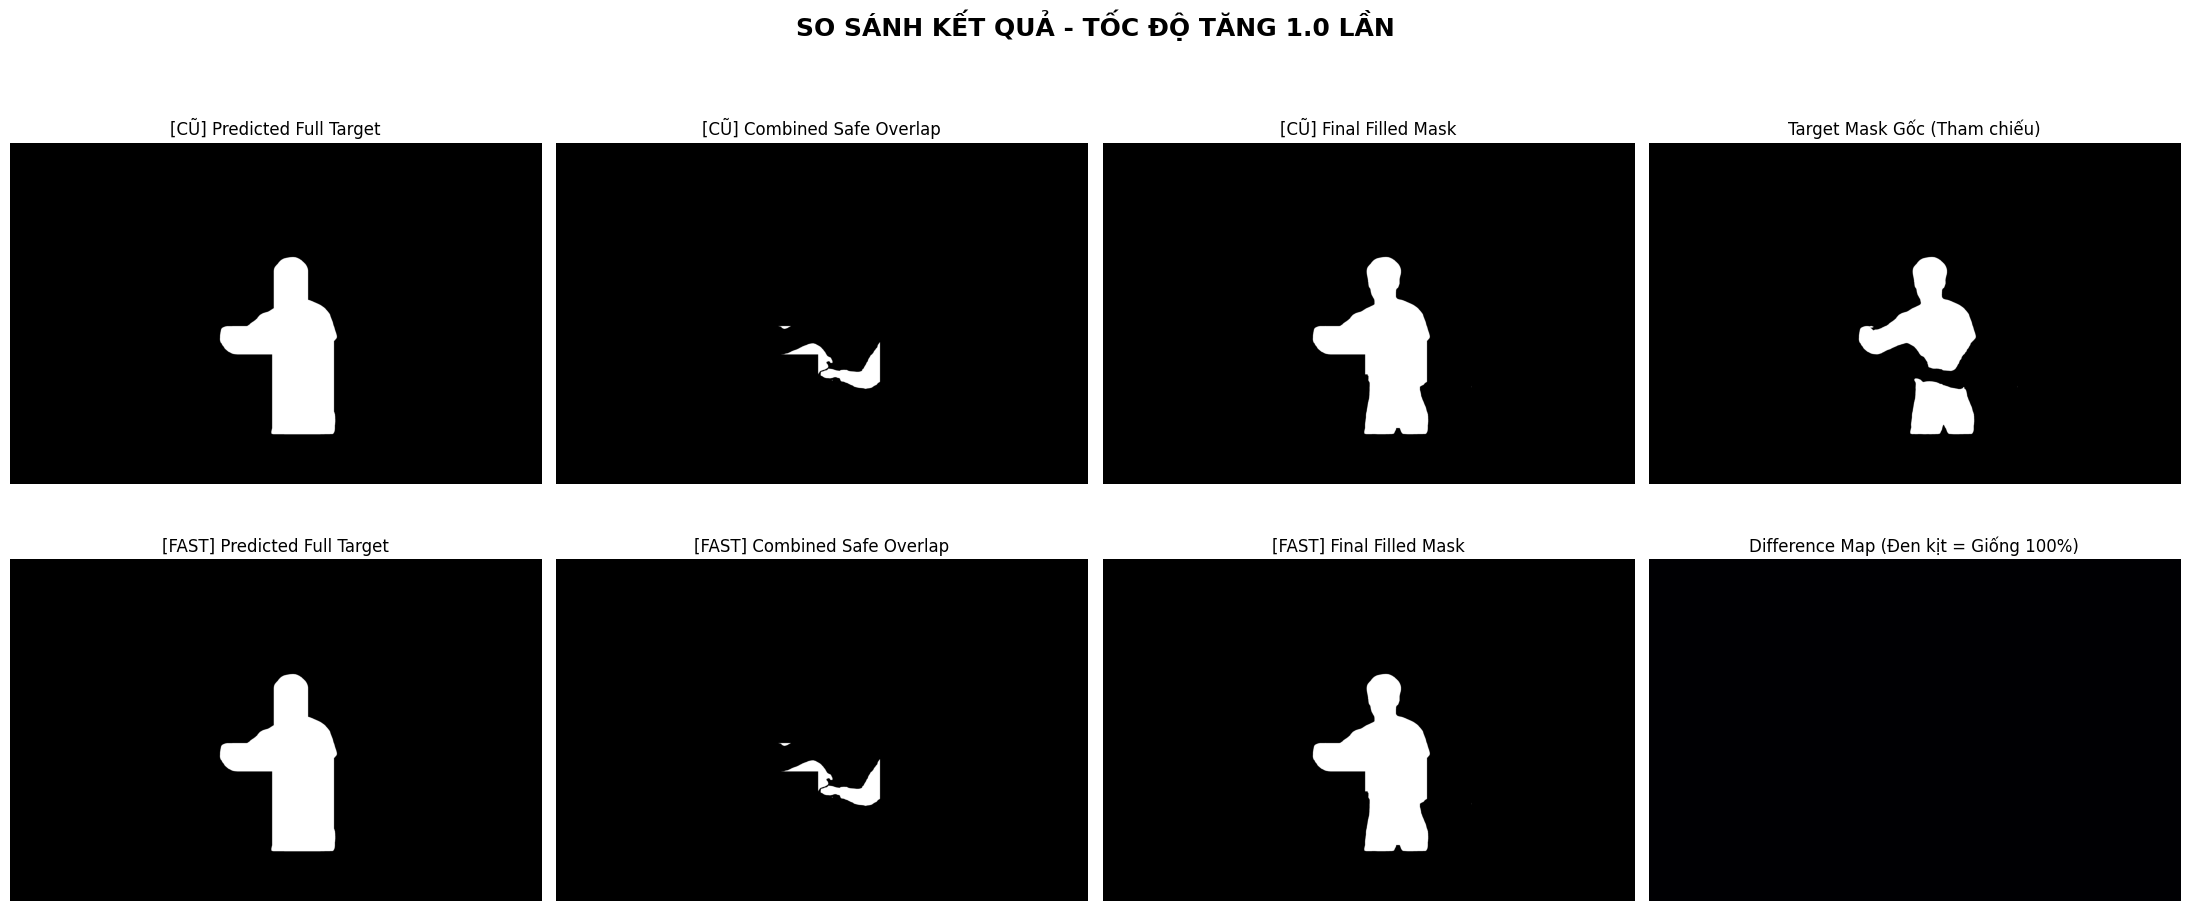

In [33]:
import time
import numpy as np
import matplotlib.pyplot as plt
import cv2

num_iterations = 20

print("--- 🚀 BẮT ĐẦU BENCHMARK: HÀM CŨ vs HÀM FAST ---")

# ==========================================
# 1. ĐO TỐC ĐỘ HÀM CŨ
# ==========================================
start_old = time.perf_counter()
for _ in range(num_iterations):
    res_old = calculate_multi_occluder_overlap(
        target_mask=target_mask,
        bbox_target=bbox_target,
        occluder_masks=occluder_masks,
        bbox_occluders=bbox_occluders
    )
time_old = (time.perf_counter() - start_old) / num_iterations
print(f"🐢 Tốc độ Hàm Cũ (Quét toàn ảnh):  {time_old:.5f} giây/lần")

# ==========================================
# 2. ĐO TỐC ĐỘ HÀM MỚI (FAST)
# ==========================================
start_fast = time.perf_counter()
for _ in range(num_iterations):
    res_fast = calculate_multi_occluder_overlap_fast(
        target_mask=target_mask,
        bbox_target=bbox_target,
        occluder_masks=occluder_masks,
        bbox_occluders=bbox_occluders
    )
time_fast = (time.perf_counter() - start_fast) / num_iterations
print(f"⚡ Tốc độ Hàm Mới (Cắt ROI + Bool): {time_fast:.5f} giây/lần")

# ==========================================
# 3. KẾT LUẬN & KIỂM TRA ĐỘ CHÍNH XÁC
# ==========================================
speedup = time_old / time_fast if time_fast > 0 else 0
print(f"🏆 KẾT LUẬN: Hàm Mới nhanh hơn {speedup:.2f} lần!\n")

# Bóc tách kết quả
pred_old, zone_old, overlap_old, final_old = res_old
pred_fast, zone_fast, overlap_fast, final_fast = res_fast

# Kiểm tra pixel-perfect
is_identical = np.array_equal(final_old, final_fast) and np.array_equal(overlap_old, overlap_fast)
print(f"🔍 Kiểm tra chéo: Kết quả Pixel giữa 2 hàm giống nhau 100%: {is_identical}\n")

# ==========================================
# 4. TRỰC QUAN HÓA (VISUALIZE)
# ==========================================
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle(f"SO SÁNH KẾT QUẢ - TỐC ĐỘ TĂNG {speedup:.1f} LẦN", fontsize=18, fontweight='bold')

# --- HÀNG 1: HÀM CŨ ---
axes[0, 0].set_title(f"[CŨ] Predicted Full Target", fontsize=12)
axes[0, 0].imshow(pred_old, cmap='gray')

axes[0, 1].set_title(f"[CŨ] Combined Safe Overlap", fontsize=12)
axes[0, 1].imshow(overlap_old, cmap='gray')

axes[0, 2].set_title(f"[CŨ] Final Filled Mask", fontsize=12)
axes[0, 2].imshow(final_old, cmap='gray')

# Target gốc (để tham chiếu)
axes[0, 3].set_title("Target Mask Gốc (Tham chiếu)", fontsize=12)
axes[0, 3].imshow(target_mask, cmap='gray')


# --- HÀNG 2: HÀM MỚI (FAST) ---
axes[1, 0].set_title(f"[FAST] Predicted Full Target", fontsize=12)
axes[1, 0].imshow(pred_fast, cmap='gray')

axes[1, 1].set_title(f"[FAST] Combined Safe Overlap", fontsize=12)
axes[1, 1].imshow(overlap_fast, cmap='gray')

axes[1, 2].set_title(f"[FAST] Final Filled Mask", fontsize=12)
axes[1, 2].imshow(final_fast, cmap='gray')

# Bản đồ chênh lệch (Difference Map)
# Nếu 2 ảnh giống hệt nhau, phép trừ tuyệt đối sẽ ra ma trận toàn số 0 (Màu đen hoàn toàn)
diff_map = cv2.absdiff(final_old, final_fast)
axes[1, 3].set_title("Difference Map (Đen kịt = Giống 100%)", fontsize=12)
axes[1, 3].imshow(diff_map, cmap='magma') # Dùng colormap magma để làm nổi bật bất kỳ sai số nào (nếu có)

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

# Active Contour

# MorphologyEx

Text(0.5, 1.0, 'Dự đoán hình dáng đầy đủ sau Closing')

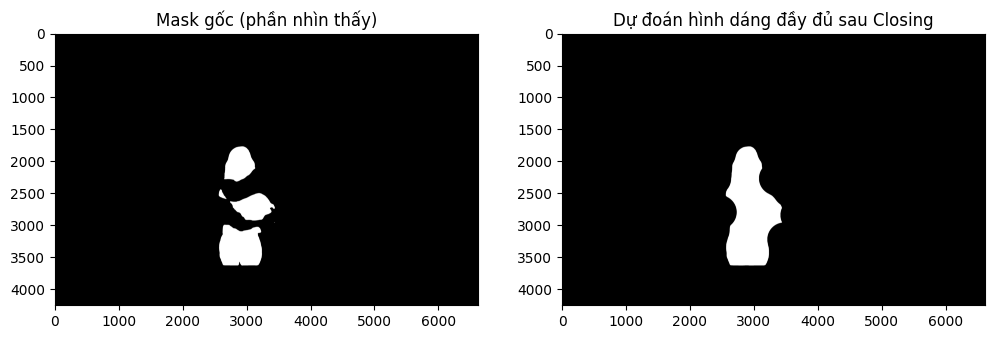

In [ ]:
target_mask = raw_masks[5]  # Ví dụ mask của vật thể cần khôi phục
bbox_target = _bbox_from_mask(target_mask)
_, _, w, h = bbox_target
close_k_size = max(15, int(min(w, h) * 0.6)) # Tinh chỉnh 0.25 tùy ý
kernel_close = cv2.getStructuringElement(cv2.MORPH_RECT, (close_k_size, close_k_size))

target_u8 = (target_mask.astype(np.uint8) * 255)
# 3. Phục hồi hình dáng vật thể bị che khuất (Dùng Closing thay thế hoàn toàn)
predicted_full_target = cv2.morphologyEx(target_u8, cv2.MORPH_CLOSE, kernel_close)


plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.imshow(target_mask, cmap='gray')
plt.title("Mask gốc (phần nhìn thấy)")

plt.subplot(1,2,2)
plt.imshow(predicted_full_target, cmap='gray')
plt.title("Dự đoán hình dáng đầy đủ sau Closing")

In [ ]:
hull_mask = np.zeros_like(target_mask, dtype=np.uint8)
contours, _ = cv2.findContours(target_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    all_points = np.vstack(contours)
    hull = cv2.convexHull(all_points)
    cv2.fillPoly(hull_mask, [hull], 255)

predicted_full_target = cv2.bitwise_or(dilated_target, hull_mask)

occluder_u8 = (occluder_mask.astype(np.uint8) * 255)
raw_overlap = cv2.bitwise_and(predicted_full_target, occluder_u8)
safe_overlap = cv2.bitwise_and(raw_overlap, safe_zone_mask)

197


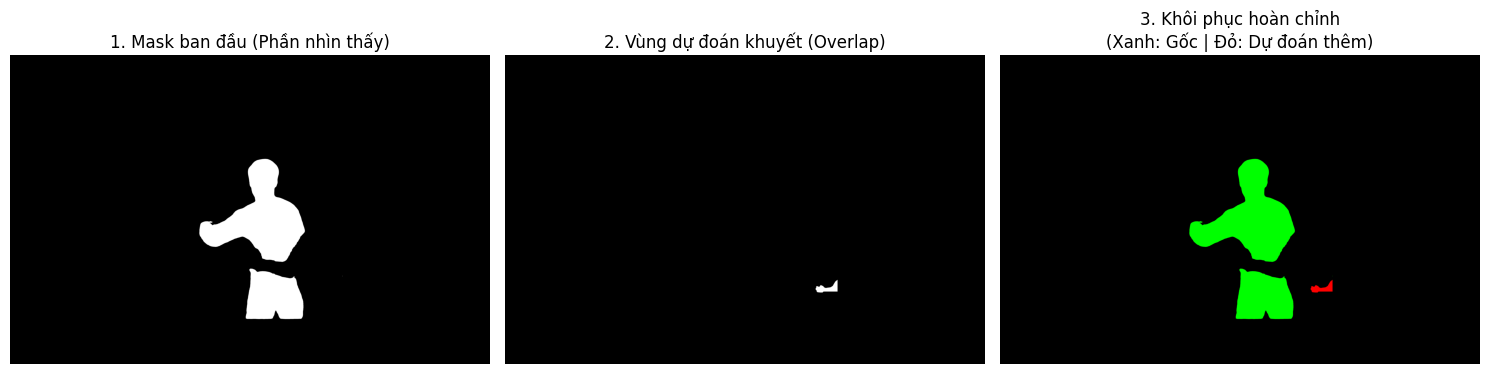

: 

In [ ]:
overlap_mask = _calculate_amodal_overlap(raw_masks[4], raw_masks[2]) if len(raw_masks) >= 2 else None
visualize_amodal_recovery(raw_masks[4], overlap_mask)

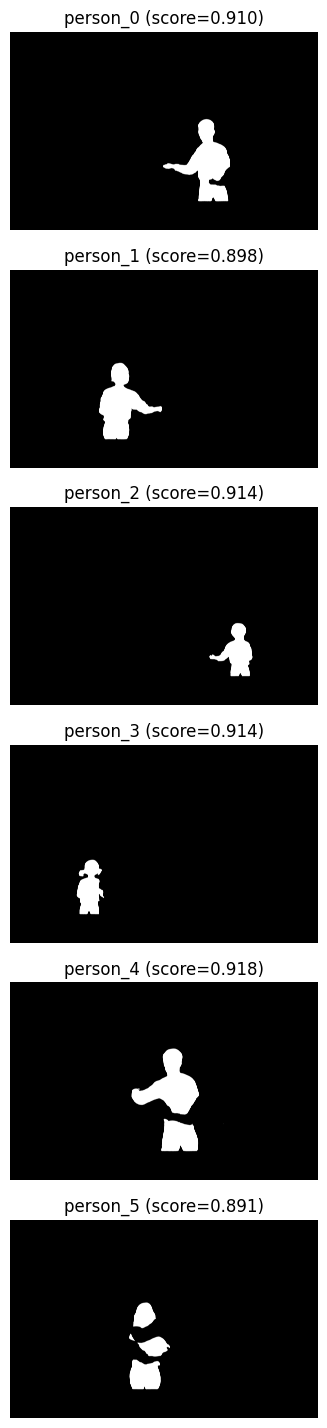

In [5]:
# Hiển thị mask SAM3
n = len(raw_masks)
if n == 0:
    raise RuntimeError('Không có mask nào để hiển thị.')
plt.figure(figsize=(12, 3 * n))
for i, mask in enumerate(raw_masks):
    plt.subplot(n, 1, i + 1)
    plt.imshow(mask, cmap='gray')
    plt.title(f'{labels[i]} (score={scores[i]:.3f})')
    plt.axis('off')

In [6]:
# Chạy matting để sinh soft alpha cho mỗi mask
matting_model = get_matting_model()
soft_alphas = []
hard_masks = []
for idx, m_bin in enumerate(raw_masks):
    guided = image_np.copy()
    guided[m_bin == 0] = 0
    alpha_f = matting_model(Image.fromarray(guided))
    hard = alpha_f > _TH_ALPHA
    m_bin_tensor = torch.from_numpy(m_bin).to(alpha_f.device) > 0
    hard = hard & m_bin_tensor
    hard = hard.bool()
    alpha_f[~hard] = 0.0
    alpha_np = alpha_f.cpu().to(torch.float64).numpy()
    alpha_np = np.clip(alpha_np, 0.0, 1.0)
    soft_alphas.append(alpha_np)
    hard_masks.append(hard.cpu().numpy())
    print(f'Matting xong mask {labels[idx]} shape={alpha_np.shape}')

[Matting] Loading BiRefNet on cuda...


Loading weights:   0%|          | 0/754 [00:00<?, ?it/s]

[Matting] Model loaded.
Matting xong mask person_0 shape=(4252, 6614)
Matting xong mask person_1 shape=(4252, 6614)
Matting xong mask person_2 shape=(4252, 6614)
Matting xong mask person_3 shape=(4252, 6614)
Matting xong mask person_4 shape=(4252, 6614)
Matting xong mask person_5 shape=(4252, 6614)


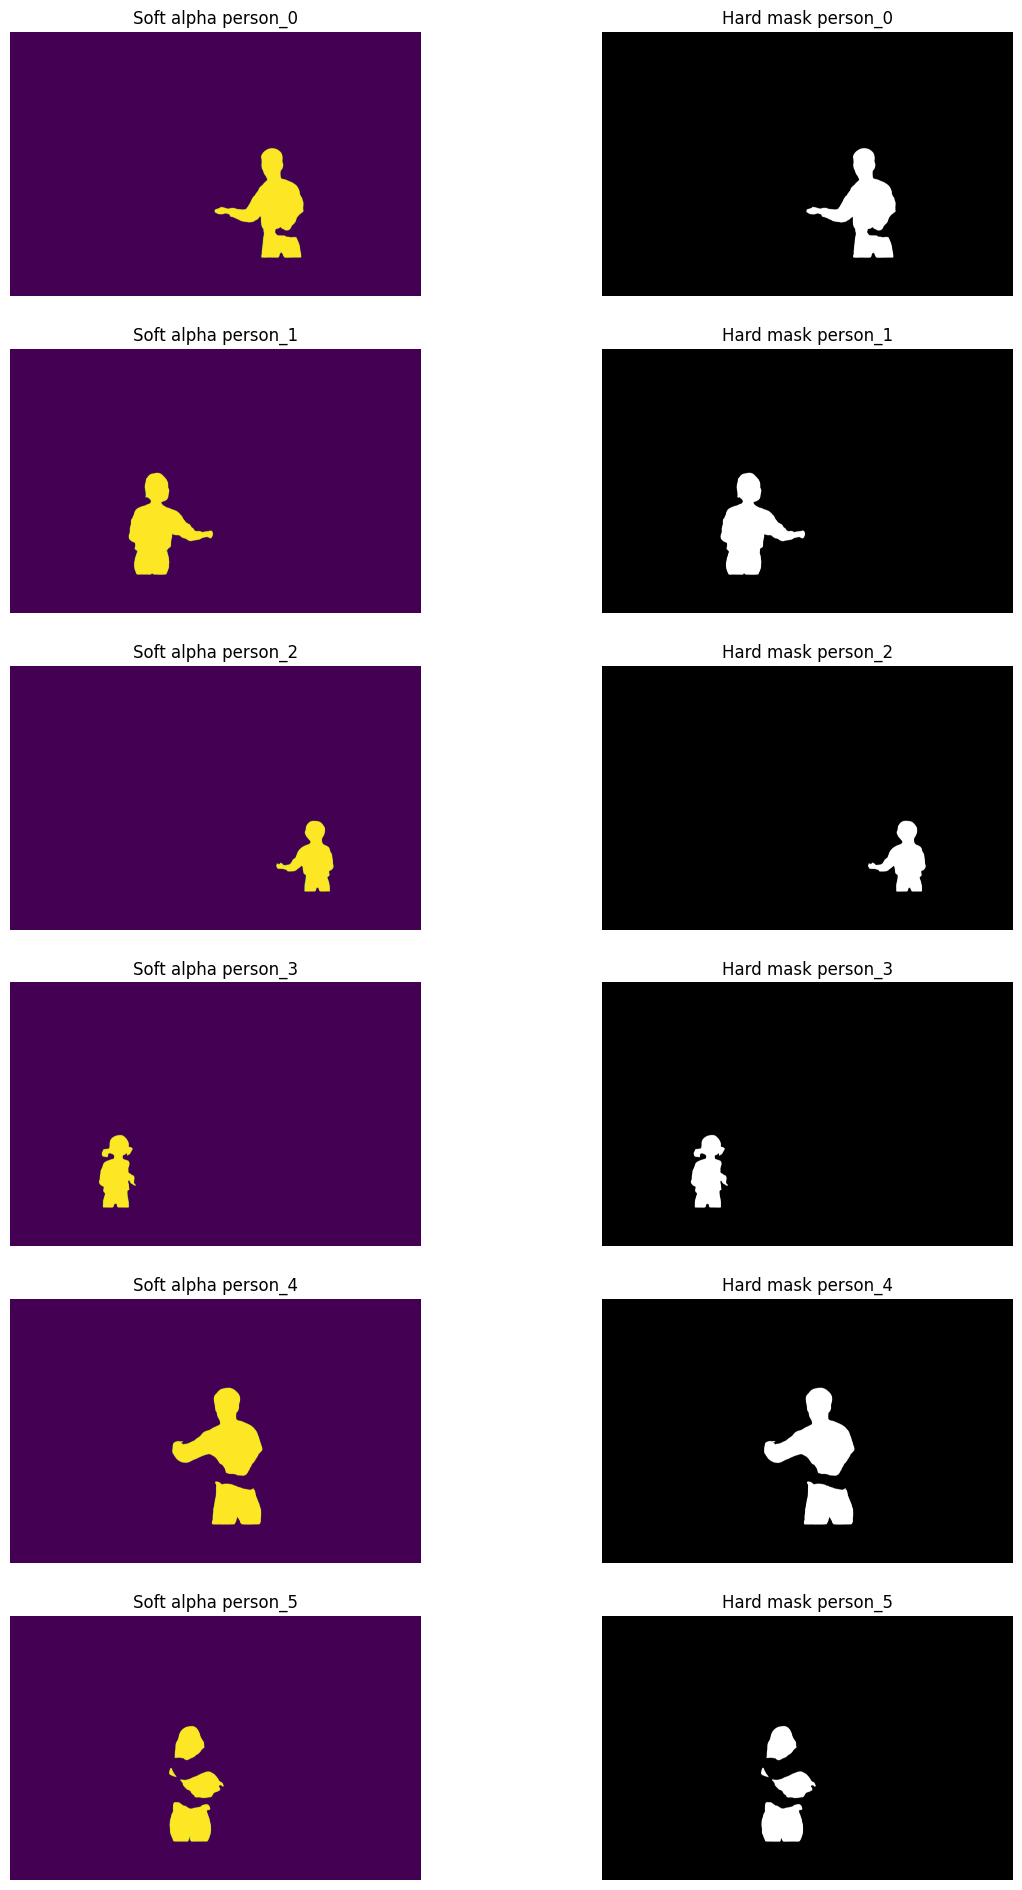

In [7]:
# Hiển thị soft alpha và hard mask
plt.figure(figsize=(14, 4 * len(soft_alphas)))
for i, alpha in enumerate(soft_alphas):
    plt.subplot(len(soft_alphas), 2, 2 * i + 1)
    plt.imshow(alpha, cmap='viridis')
    plt.title(f'Soft alpha {labels[i]}')
    plt.axis('off')
    plt.subplot(len(soft_alphas), 2, 2 * i + 2)
    plt.imshow(hard_masks[i], cmap='gray')
    plt.title(f'Hard mask {labels[i]}')
    plt.axis('off')

In [8]:
# Ước tính depth order
depth_order = _estimate_depth_order(raw_masks)
print('Depth order (top->bottom):', depth_order)
for rank, idx in enumerate(depth_order):
    print(f'  position {rank}: {labels[idx]}')

Depth order (top->bottom): [1, 3, 4, 0, 2, 5]
  position 0: person_1
  position 1: person_3
  position 2: person_4
  position 3: person_0
  position 4: person_2
  position 5: person_5


In [9]:
# Inpaint background cho từng vật thể, loại bỏ occluder phía trên
lama = get_lama_model()
orig_size = image.size
object_sources = []
with torch.inference_mode():
    for idx in range(len(raw_masks)):
        source_np = _build_source_image_for_object(original_np=image_np, masks=raw_masks, target_idx=idx, depth_order=depth_order, lama=lama, orig_size=orig_size)
        torch.cuda.empty_cache()
        object_sources.append(source_np)
        print(f'Đã tạo source image cho {labels[idx]}')

RuntimeError: The following operation failed in the TorchScript interpreter.
Traceback of TorchScript, serialized code (most recent call last):
  File "code/__torch__.py", line 11, in forward
    mask: Tensor) -> Tensor:
    model = self.model
    return (model).forward(mask, image, )
            ~~~~~~~~~~~~~~ <--- HERE
  File "code/__torch__/saicinpainting/training/trainers/default.py", line 13, in forward
    masked_img = torch.mul(image, torch.rsub(mask, 1))
    input = torch.cat([masked_img, mask], 1)
    _0 = torch.mul(mask, (generator).forward(input, ))
                          ~~~~~~~~~~~~~~~~~~ <--- HERE
    _1 = torch.mul(torch.rsub(mask, 1), image)
    return torch.add(_0, _1)
  File "code/__torch__/saicinpainting/training/modules/ffc.py", line 10, in forward
    input: Tensor) -> Tensor:
    model = self.model
    return (model).forward(input, )
            ~~~~~~~~~~~~~~ <--- HERE
class FFC_BN_ACT(Module):
  __parameters__ = []
  File "code/__torch__/torch/nn/modules/cont

In [ ]:
# Hiển thị ảnh nguồn sau khi loại bỏ occluder
plt.figure(figsize=(12, 4 * len(object_sources)))
for i, src in enumerate(object_sources):
    plt.subplot(len(object_sources), 1, i + 1)
    plt.imshow(src)
    plt.title(f'Source image cho {labels[i]}')
    plt.axis('off')

In [ ]:
# Refine background và alpha cho từng layer
layer_rgba = []
kernel_size = _calc_kernel_size(image_np)
for idx, (source_np, alpha, label) in enumerate(zip(object_sources, soft_alphas, labels)):
    hard_mask = alpha > _TH_ALPHA
    inpaint_mask_fg = _build_inpaint_mask(source_np, hard_mask, kernel_size)
    mask_pil = Image.fromarray(inpaint_mask_fg).convert('L')
    source_img = Image.fromarray(source_np)
    bg_pil = lama(source_img, mask_pil)
    if bg_pil.size != orig_size:
        bg_pil = bg_pil.resize(orig_size, Image.LANCZOS)
    bg_np = np.array(bg_pil.convert('RGB'), dtype=np.uint8)
    bg_np = refine_background(bg_np, inpaint_mask_fg.astype(bool), n_outer_ratio=_BG_REFINE_N_OUTER_RATIO, max_num_colors=_BG_REFINE_NUM_COLORS)
    alpha_refined, fg_rgb = _refine_alpha_with_colors(source_np, bg_np, alpha.copy(), hard_mask, kernel_size)
    bbox = _bbox_from_mask((alpha_refined > _TH_ALPHA).astype(np.uint8) * 255)
    if bbox is None:
        continue
    x, y, w, h = bbox
    fg_crop = fg_rgb[y:y+h, x:x+w]
    alpha_crop = (alpha_refined[y:y+h, x:x+w] * 255).astype(np.uint8)
    rgba_arr = np.dstack([fg_crop, alpha_crop])
    layer_rgba.append((label, Image.fromarray(rgba_arr, mode='RGBA'), bg_np, inpaint_mask_fg))
    print(f'Layer {label} tạo xong, bbox={bbox}')

In [ ]:
# Hiển thị layer RGBA và background refined cho từng object
plt.figure(figsize=(14, 5 * len(layer_rgba)))
for i, (label, rgba_img, bg_np, mask) in enumerate(layer_rgba):
    plt.subplot(len(layer_rgba), 3, 3 * i + 1)
    plt.imshow(rgba_img)
    plt.title(f'RGBA {label}')
    plt.axis('off')
    plt.subplot(len(layer_rgba), 3, 3 * i + 2)
    plt.imshow(bg_np)
    plt.title(f'Background refined {label}')
    plt.axis('off')
    plt.subplot(len(layer_rgba), 3, 3 * i + 3)
    plt.imshow(mask, cmap='gray')
    plt.title(f'Inpaint mask {label}')
    plt.axis('off')

In [ ]:
# Inpaint background tổng thể với union mask
union_mask = np.zeros_like(raw_masks[0])
for m in raw_masks:
    union_mask = np.maximum(union_mask, m)
union_mask = expand_mask(union_mask > 0, kernel_size)
final_bg = lama(image, Image.fromarray(union_mask).convert('L'))
if final_bg.size != orig_size:
    final_bg = final_bg.resize(orig_size, Image.LANCZOS)
final_bg_np = np.array(final_bg.convert('RGB'), dtype=np.uint8)
final_bg_np = refine_background(final_bg_np, union_mask.astype(bool), n_outer_ratio=_BG_REFINE_N_OUTER_RATIO, max_num_colors=_BG_REFINE_NUM_COLORS)
plt.figure(figsize=(10, 8))
plt.imshow(final_bg_np)
plt.title('Background tổng thể đã inpaint')
plt.axis('off')

In [ ]:
# Hiển thị tất cả các layer và background cuối cùng
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(final_bg_np)
plt.title('Background cuối cùng')
plt.axis('off')
plt.subplot(1, 2, 2)
combined = Image.new('RGBA', image.size, (0, 0, 0, 0))
for label, rgba_img, _, _ in layer_rgba:
    combined.alpha_composite(rgba_img)
plt.imshow(combined)
plt.title('Tổng hợp layers RGBA')
plt.axis('off')